<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M7_VC_Biotech_Valuacion_Integrada_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M7 — Valuación Integrada de Bioemprendimientos LATAM
## Módulos Cruzados: EDA + XGBoost + KMeans + Prophet + LTV/CAC + VC Method

**Caso de uso:** BioDetect LATAM — empresa de diagnóstico molecular de cáncer de mama  
*(Diagnóstico temprano por biopsia líquida, mercado B2B hospitales/clínicas privadas)*  
*(Inspirado en casos reales: Grail, Guardant Health, y startups de biotech LATAM como Simbiosis, Gnotobiotics)*

---

## Por qué los bioemprendimientos necesitan un enfoque diferente

Un bioemprendimiento **NO** es una startup de software. Las diferencias son fundamentales:

| Dimensión | SaaS/FinTech | Biotech/Medtech |
|-----------|-------------|------------------|
| Tiempo al mercado | 6-18 meses | 3-10 años |
| Costo de desarrollo | $100K-$2M | $5M-$500M |
| Barrera regulatoria | Baja-media | Muy alta (COFEPRIS, ANVISA, FDA) |
| Riesgo técnico | Bajo-medio | Alto (tasa de fallo 90%+) |
| Adopción del mercado | Viral posible | S-curve lenta (3-7 años) |
| Métricas de éxito | MAU, ARR, Churn | Sensibilidad, Especificidad, p-valor |
| Tipo de inversor | VC generalista | VC especializado, CVC farmacéutica |

Por estas razones, la valuación de un bioemprendimiento **sin datos históricos** requiere:
1. Modelar la **probabilidad de éxito técnico y regulatorio** explícitamente
2. Usar **S-curves de adopción** en lugar de crecimiento exponencial
3. Proyectar **unit economics basados en benchmarks** del sector, no en datos reales
4. Aplicar **múltiplos de salida específicos de biotech** (EV/Revenue o EV/Pipeline value)
5. Hacer análisis de sensibilidad robusto porque la **incertidumbre es estructural**

---

## Cadena de dependencias entre módulos

```
INPUTS DEL FUNDADOR
       │
       ▼
[SECCION 3] M1-EDA: Validación de supuestos de entrada
       │ → Outputs: supuestos validados, alertas de inconsistencia
       ▼
[SECCION 4] M2-XGBoost: Probabilidad de éxito técnico/regulatorio
       │ → Output: p_exito (0-1) — factor de descuento de riesgo
       ▼
[SECCION 5] M4-KMeans: Segmentación de mercado potencial
       │ → Output: segmentos priorizados, TAM/SAM por segmento
       ▼
[SECCION 6] M5-Prophet/S-curve: Proyección de adopción
       │ → Output: curva de usuarios/pacientes/año
       ▼
[SECCION 7] M3-LTV/CAC: Unit economics por segmento
       │ → Output: LTV, CAC, margen por segmento
       ▼
[SECCION 8] M6-VC Method: Valuación final ajustada por riesgo
       │ → Input: proyecciones de revenue, p_exito, múltiplos biotech
       ▼
[SECCION 9] Análisis de sensibilidad multivariable
       │ → Output: heatmaps de valuación bajo escenarios
       ▼
  DASHBOARD EJECUTIVO + RECOMENDACIONES
```

---

> **Disclaimer:** Los resultados son ilustrativos. Para valuaciones en negociaciones reales con inversores, validar con un asesor especializado en biotech VC y con datos de transacciones comparables actualizados.
>
> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

In [1]:
# Instala las dependencias necesarias (ejecuta solo una vez en Google Colab)
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost scipy -q

## Sección 2: Parámetros de entrada del bioemprendimiento

**Esta es la sección que debes personalizar con los datos de tu empresa.**

Los parámetros están organizados en bloques temáticos. Lee los comentarios — explican qué valor poner y de dónde obtenerlo.

**Caso de referencia:** BioDetect LATAM — diagnóstico molecular temprano de cáncer de mama  
Tecnología: biopsia líquida ctDNA, sensibilidad clínica validada en laboratorio  
Etapa actual: validación pre-clínica completada, buscando Seed de $3M USD

In [2]:
# ════════════════════════════════════════════════════════════════════════
# PARAMETROS DE ENTRADA — EDITAR CON DATOS REALES DE TU BIOEMPRENDIMIENTO
# ════════════════════════════════════════════════════════════════════════

BIOTECH = {
    # ── IDENTIFICACION ──────────────────────────────────────────────────
    'nombre':            'BioDetect LATAM',
    'tipo':              'Diagnóstico Molecular',  # Diagnóstico / Terapéutico / AgriTech / Síntesis
    'tecnologia':        'Biopsia líquida ctDNA',
    'indicacion':        'Cáncer de mama estadio I-II',
    'pais_principal':    'México',
    'etapa_ronda':       'Seed',           # Seed / Serie A / Serie B
    'moneda':            'USD',

    # ── COSTOS DE DESARROLLO (en USD) ──────────────────────────────────
    # Benchmark global: $10M-$50M para diagnóstico, $50M-$500M para terapéutico
    'costo_rd_total':        8_000_000,   # R&D hasta validación clínica completa
    'costo_regulatorio':     2_500_000,   # Registro COFEPRIS/ANVISA + estudios
    'costo_manufactura':     1_200_000,   # Setup de manufactura / COGS setup
    'costo_go_to_market':    1_500_000,   # Fuerza de ventas, certificaciones
    'capex_laboratorio':       800_000,   # Equipamiento y laboratorio

    # ── TIMELINE (en años desde hoy) ────────────────────────────────────
    # Benchmark diagnóstico LATAM: regulatorio 2-4 años; terapéutico 5-10 años
    'anos_validacion_clinica':   2.0,    # hasta tener datos clínicos publicables
    'anos_aprobacion_regulatoria': 3.5,  # hasta registro sanitario (COFEPRIS/ANVISA)
    'anos_primer_revenue':         4.0,  # primer contrato pagado
    'anos_break_even':             7.0,  # año en que flujo operativo = 0
    'horizonte_exit':              8,    # años hasta exit (adquisición o IPO)

    # ── MERCADO POTENCIAL (TAM/SAM/SOM en USD) ──────────────────────────
    # TAM: mercado global de diagnóstico molecular oncológico
    # SAM: LATAM (México, Brasil, Argentina, Colombia, Chile)
    # SOM: captura realista en primeros 5 años
    'tam_usd':          4_200_000_000,   # $4.2B — diagnóstico oncológico LATAM
    'sam_usd':            840_000_000,   # $840M — México + Brasil foco inicial
    'som_usd':             42_000_000,   # $42M — 5% SAM en 5 años post-launch
    'precio_prueba_usd':        380,     # precio por prueba diagnóstica en USD
    'precio_kit_anual_usd':   4_500,     # precio contrato anual hospital (kit+servicio)

    # ── ADOPCION (parámetros S-curve) ───────────────────────────────────
    # K = saturación (máximo de hospitales/clínicas a capturar)
    # r = tasa de crecimiento de la S-curve (0.3-0.8 en biotech diagnóstico)
    # t0 = año de inflexión (mitad de la adopción máxima)
    'hospitales_target_latam':  1_200,   # hospitales privados con oncología en SAM
    'scurve_K':                   900,   # saturación máxima alcanzable (75% del target)
    'scurve_r':                   0.55,  # tasa de crecimiento (benchmark diagnóstico: 0.4-0.7)
    'scurve_t0':                  5.5,   # año de inflexión post-inicio de ventas
    'pruebas_por_hospital_año':   180,   # pruebas anuales promedio por hospital cliente

    # ── UNIT ECONOMICS (proyectados, sin datos históricos) ──────────────
    # Benchmark diagnóstico molecular: GM 65-80%, CAC B2B $5K-$25K
    'margen_bruto':              0.68,   # margen bruto sobre precio de prueba
    'cac_hospital':          12_000,     # CAC por hospital (visitas médicas + demos + contratos)
    'churn_anual_hospitales':   0.08,    # hospitales que cancelan por año (benchmark B2B: 5-12%)
    'expansion_revenue_rate':   0.15,    # % de hospitales que amplían volumen anualmente
    'costo_fijo_anual':      1_800_000,  # OPEX anual (equipo, infraestructura, compliance)

    # ── RIESGO TECNICO Y REGULATORIO ────────────────────────────────────
    # Probabilidades de transición de fase (basadas en benchmarks industria)
    # Benchmark diagnóstico IVD: ~40-60% llegan a mercado desde pre-clínico
    'p_exito_validacion':       0.75,    # prob. de pasar validación clínica
    'p_aprobacion_regulatoria': 0.70,    # prob. de aprobación regulatoria
    'p_adopcion_mercado':       0.80,    # prob. de lograr adopción mínima viable

    # ── FINANCIAMIENTO ──────────────────────────────────────────────────
    'inversion_buscada':    3_000_000,   # monto de la ronda Seed en USD
    'burn_mensual_actual':     95_000,   # burn rate actual (pre-revenue)
    'runway_actual_meses':         18,   # runway con caja actual

    # ── PARAMETROS DE VALUACION BIOTECH ─────────────────────────────────
    # Múltiplos EV/Revenue típicos en biotech diagnóstico (exit)
    # Benchmark: Guardant Health IPO ~15x; adquisiciones diagnóstico 8-20x revenue
    'multiple_exit_base':       12.0,
    'multiple_exit_opt':        18.0,
    'multiple_exit_pes':         6.0,
    'irr_objetivo_fondo':        0.30,   # IRR típico biotech VC: 25-35%
    'dilution_futuras':          0.45,   # mayor dilución por rondas múltiples en biotech
}

## Importaciones y configuración global

In [3]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from scipy.optimize import curve_fit
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

np.random.seed(42)

# Paleta de colores corporativa para biotech
COLORES = {
    'primario':   '#1A5276',   # azul oscuro científico
    'secundario': '#148F77',   # verde teal (vida/salud)
    'alerta':     '#C0392B',   # rojo peligro
    'advertencia':'#E67E22',   # naranja advertencia
    'exito':      '#27AE60',   # verde éxito
    'neutro':     '#7F8C8D',   # gris neutro
    'acento':     '#8E44AD',   # púrpura para proyecciones
    'base':       '#2980B9',   # azul medio
    'fondo':      '#EBF5FB',   # fondo suave
}

plt.rcParams.update({
    'figure.figsize':   (16, 9),
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print(f"Bioemprendimiento cargado: {BIOTECH['nombre']}")
print(f"Tipo:                      {BIOTECH['tipo']}")
print(f"Tecnología:                {BIOTECH['tecnologia']}")
print(f"Indicación:                {BIOTECH['indicacion']}")
print(f"País principal:            {BIOTECH['pais_principal']}")
print(f"Ronda buscada:             {BIOTECH['etapa_ronda']} — ${BIOTECH['inversion_buscada']/1e6:.1f}M USD")
print()
costo_total = (BIOTECH['costo_rd_total'] + BIOTECH['costo_regulatorio'] +
               BIOTECH['costo_manufactura'] + BIOTECH['costo_go_to_market'] +
               BIOTECH['capex_laboratorio'])
print(f"Costo total estimado:      ${costo_total/1e6:.1f}M USD")
print(f"Años hasta primer revenue: {BIOTECH['anos_primer_revenue']}")
print(f"Probabilidad éxito global: {BIOTECH['p_exito_validacion'] * BIOTECH['p_aprobacion_regulatoria'] * BIOTECH['p_adopcion_mercado']:.1%}")

Bioemprendimiento cargado: BioDetect LATAM
Tipo:                      Diagnóstico Molecular
Tecnología:                Biopsia líquida ctDNA
Indicación:                Cáncer de mama estadio I-II
País principal:            México
Ronda buscada:             Seed — $3.0M USD

Costo total estimado:      $14.0M USD
Años hasta primer revenue: 4.0
Probabilidad éxito global: 42.0%


---
## Sección 3: Análisis de supuestos (M1-EDA Style)

Antes de proyectar cualquier número, debemos validar que los supuestos de entrada son **internamente consistentes** y **razonables** para el sector.

Este análisis reemplaza el EDA tradicional (que requiere datos históricos) con un **EDA de supuestos**: verificamos rangos, relaciones lógicas, y comparamos con benchmarks del sector biotech LATAM.

**Regla de oro:** si un supuesto está fuera del rango de la industria, el modelo lo detecta y emite una alerta. El fundador puede mantener el supuesto (con justificación) o ajustarlo.

In [4]:
# ════════════════════════════════════════════════════════════════════
# VALIDACIONES DE RANGO Y CONSISTENCIA
# ════════════════════════════════════════════════════════════════════

alertas = []
aprobaciones = []

def check(condicion, mensaje_ok, mensaje_alerta, critico=False):
    """Evalúa una condición y registra el resultado."""
    nivel = 'CRITICO' if critico else 'ADVERTENCIA'
    if condicion:
        aprobaciones.append(f'  OK  {mensaje_ok}')
    else:
        alertas.append(f'  [{nivel}] {mensaje_alerta}')

# --- Consistencia TAM > SAM > SOM ---
check(BIOTECH['tam_usd'] > BIOTECH['sam_usd'],
      'TAM > SAM: consistente',
      f'SAM (${BIOTECH["sam_usd"]/1e6:.0f}M) >= TAM — revisar definiciones de mercado', critico=True)

check(BIOTECH['sam_usd'] > BIOTECH['som_usd'],
      'SAM > SOM: consistente',
      f'SOM (${BIOTECH["som_usd"]/1e6:.0f}M) >= SAM — SOM debe ser fracción del SAM', critico=True)

# --- Penetración SOM razonable ---
pct_sam = BIOTECH['som_usd'] / BIOTECH['sam_usd']
check(pct_sam <= 0.15,
      f'SOM = {pct_sam:.1%} del SAM — razonable para biotech (benchmark: <15% en 5 años)',
      f'SOM = {pct_sam:.1%} del SAM — >15% es poco realista en biotech diagnóstico LATAM')

# --- Probabilidades en [0,1] ---
for k in ['p_exito_validacion', 'p_aprobacion_regulatoria', 'p_adopcion_mercado']:
    check(0 < BIOTECH[k] <= 1,
          f'{k} = {BIOTECH[k]:.2f} — válido',
          f'{k} = {BIOTECH[k]:.2f} — debe estar entre 0 y 1', critico=True)

# --- Benchmark costos diagnóstico ---
costo_total = (BIOTECH['costo_rd_total'] + BIOTECH['costo_regulatorio'] +
               BIOTECH['costo_manufactura'] + BIOTECH['costo_go_to_market'] +
               BIOTECH['capex_laboratorio'])
check(5_000_000 <= costo_total <= 150_000_000,
      f'Costo total ${costo_total/1e6:.1f}M — rango plausible diagnóstico IVD ($5M-$150M)',
      f'Costo total ${costo_total/1e6:.1f}M fuera del rango típico para diagnóstico IVD ($5M-$150M)')

# --- Timeline regulatorio razonable ---
check(2.0 <= BIOTECH['anos_aprobacion_regulatoria'] <= 7.0,
      f'Regulatorio: {BIOTECH["anos_aprobacion_regulatoria"]} años — razonable para LATAM (2-7 años)',
      f'Regulatorio: {BIOTECH["anos_aprobacion_regulatoria"]} años — fuera del rango típico LATAM (2-7 años)')

# --- Margen bruto biotech ---
check(0.50 <= BIOTECH['margen_bruto'] <= 0.85,
      f'Margen bruto {BIOTECH["margen_bruto"]:.0%} — dentro del rango diagnóstico (50-85%)',
      f'Margen bruto {BIOTECH["margen_bruto"]:.0%} — revisar: diagnóstico típico 50-85%')

# --- Primer revenue DESPUES de regulatorio ---
check(BIOTECH['anos_primer_revenue'] >= BIOTECH['anos_aprobacion_regulatoria'],
      'Primer revenue posterior a aprobación regulatoria — lógico',
      'Primer revenue ANTES de aprobación regulatoria — revisar: en diagnóstico IVD se requiere registro', critico=True)

# --- S-curve: saturación <= target de mercado ---
check(BIOTECH['scurve_K'] <= BIOTECH['hospitales_target_latam'],
      f'S-curve K={BIOTECH["scurve_K"]} <= {BIOTECH["hospitales_target_latam"]} hospitales target — OK',
      f'S-curve K={BIOTECH["scurve_K"]} > {BIOTECH["hospitales_target_latam"]} hospitales — imposible superar el mercado addressable', critico=True)

# --- Runway suficiente ---
check(BIOTECH['runway_actual_meses'] >= 12,
      f'Runway {BIOTECH["runway_actual_meses"]} meses — suficiente para levantar ronda',
      f'Runway {BIOTECH["runway_actual_meses"]} meses — CRITICO: menos de 12 meses, dificultad para levantar capital', critico=True)

# --- Inversion vs costo total ---
check(BIOTECH['inversion_buscada'] <= costo_total * 0.5,
      f'Inversión buscada ${BIOTECH["inversion_buscada"]/1e6:.1f}M es razonable vs costo total ${costo_total/1e6:.1f}M',
      f'Inversión buscada ${BIOTECH["inversion_buscada"]/1e6:.1f}M cubre >50% del costo total — revisar estructura de rondas')

# --- Mostrar resultados ---
print('=' * 65)
print('VALIDACION DE SUPUESTOS — BIOTECH DIAGNOSTICO LATAM')
print('=' * 65)
print(f'\nAprobaciones ({len(aprobaciones)}):')
for a in aprobaciones:
    print(a)
print(f'\nAlertas ({len(alertas)}):')
if alertas:
    for a in alertas:
        print(a)
else:
    print('  Sin alertas — todos los supuestos son internamente consistentes')
print('=' * 65)

p_exito_global = (BIOTECH['p_exito_validacion'] *
                  BIOTECH['p_aprobacion_regulatoria'] *
                  BIOTECH['p_adopcion_mercado'])
print(f'\nProbabilidad de exito global: {p_exito_global:.1%}')
print(f'  (p_validacion × p_regulatorio × p_adopcion)')
print(f'  {BIOTECH["p_exito_validacion"]:.0%} × {BIOTECH["p_aprobacion_regulatoria"]:.0%} × {BIOTECH["p_adopcion_mercado"]:.0%} = {p_exito_global:.1%}')
print(f'  Benchmark diagnóstico IVD global: 35-55% → este supuesto es {"conservador" if p_exito_global < 0.45 else "optimista"}')

VALIDACION DE SUPUESTOS — BIOTECH DIAGNOSTICO LATAM

Aprobaciones (13):
  OK  TAM > SAM: consistente
  OK  SAM > SOM: consistente
  OK  SOM = 5.0% del SAM — razonable para biotech (benchmark: <15% en 5 años)
  OK  p_exito_validacion = 0.75 — válido
  OK  p_aprobacion_regulatoria = 0.70 — válido
  OK  p_adopcion_mercado = 0.80 — válido
  OK  Costo total $14.0M — rango plausible diagnóstico IVD ($5M-$150M)
  OK  Regulatorio: 3.5 años — razonable para LATAM (2-7 años)
  OK  Margen bruto 68% — dentro del rango diagnóstico (50-85%)
  OK  Primer revenue posterior a aprobación regulatoria — lógico
  OK  S-curve K=900 <= 1200 hospitales target — OK
  OK  Runway 18 meses — suficiente para levantar ronda
  OK  Inversión buscada $3.0M es razonable vs costo total $14.0M

Alertas (0):
  Sin alertas — todos los supuestos son internamente consistentes

Probabilidad de exito global: 42.0%
  (p_validacion × p_regulatorio × p_adopcion)
  75% × 70% × 80% = 42.0%
  Benchmark diagnóstico IVD global: 35-55%

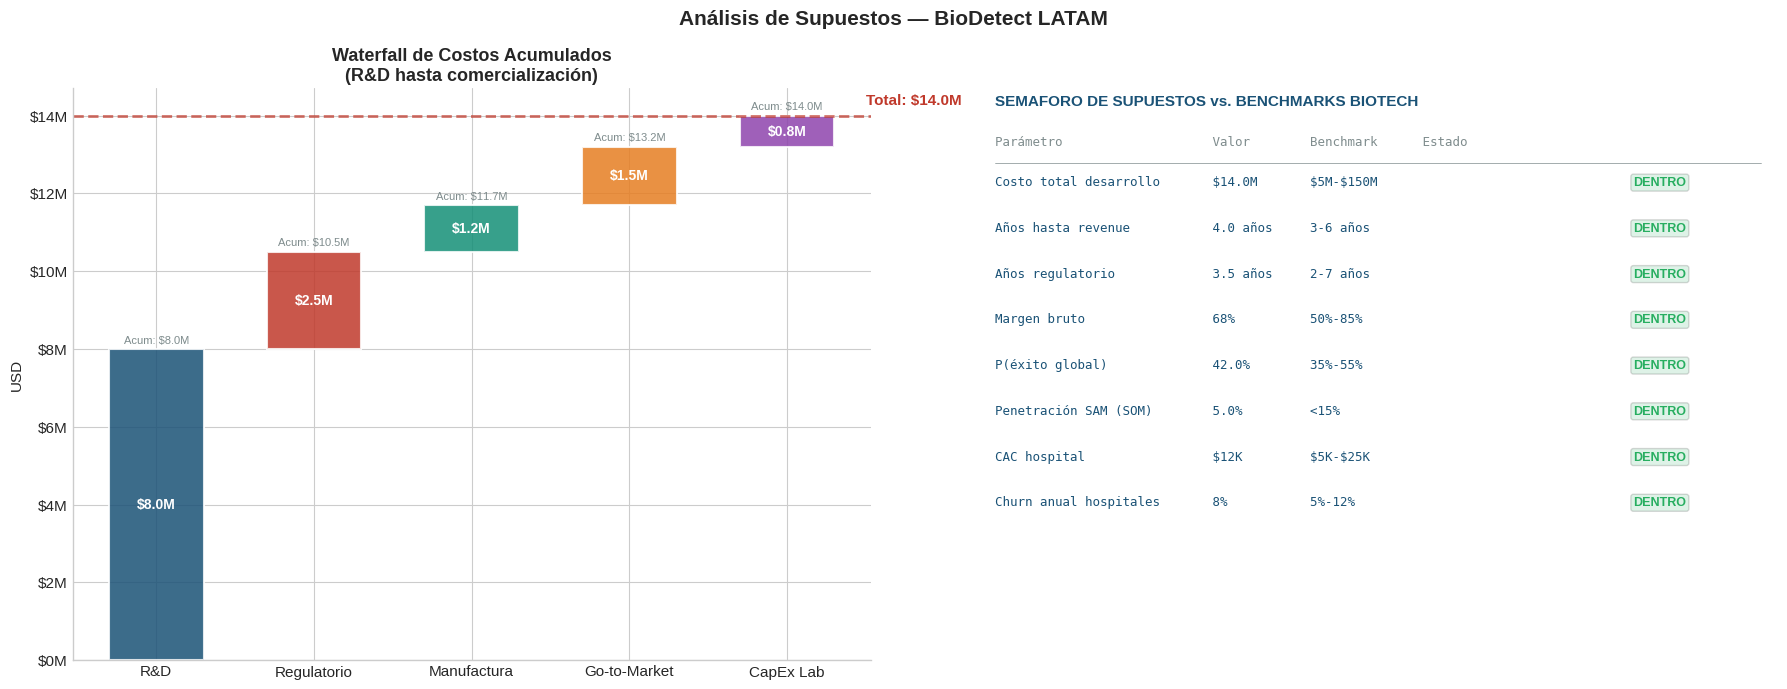

Grafico guardado: M7_01_supuestos_eda.png


In [5]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: Waterfall de costos + comparativa de supuestos
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Análisis de Supuestos — {BIOTECH["nombre"]}', fontsize=15, fontweight='bold')

# Plot 1: Waterfall de costos acumulados
ax1 = axes[0]
categorias = ['R&D', 'Regulatorio', 'Manufactura', 'Go-to-Market', 'CapEx Lab']
montos = [BIOTECH['costo_rd_total'], BIOTECH['costo_regulatorio'],
          BIOTECH['costo_manufactura'], BIOTECH['costo_go_to_market'],
          BIOTECH['capex_laboratorio']]

acumulado = np.cumsum([0] + montos[:-1])
colores_bar = [COLORES['primario'], COLORES['alerta'], COLORES['secundario'],
               COLORES['advertencia'], COLORES['acento']]

bars = ax1.bar(categorias, montos, bottom=acumulado, color=colores_bar, alpha=0.85,
               edgecolor='white', linewidth=1.5, width=0.6)

for bar, monto, acc in zip(bars, montos, acumulado):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + monto/2,
             f'${monto/1e6:.1f}M', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')
    ax1.text(bar.get_x() + bar.get_width()/2, acc + monto + 100_000,
             f'Acum: ${(acc+monto)/1e6:.1f}M', ha='center', va='bottom',
             fontsize=8, color=COLORES['neutro'])

ax1.axhline(y=costo_total, color=COLORES['alerta'], linestyle='--', lw=2, alpha=0.7)
ax1.text(len(categorias)-0.5, costo_total * 1.02,
         f'Total: ${costo_total/1e6:.1f}M', color=COLORES['alerta'],
         fontsize=11, fontweight='bold')
ax1.set_title('Waterfall de Costos Acumulados\n(R&D hasta comercialización)')
ax1.set_ylabel('USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# Plot 2: Semáforo de supuestos vs benchmarks
ax2 = axes[1]
ax2.axis('off')

benchmarks = [
    ('Costo total desarrollo', f'${costo_total/1e6:.1f}M', '$5M-$150M', 5e6 <= costo_total <= 150e6),
    ('Años hasta revenue', f'{BIOTECH["anos_primer_revenue"]} años', '3-6 años', 3 <= BIOTECH['anos_primer_revenue'] <= 6),
    ('Años regulatorio', f'{BIOTECH["anos_aprobacion_regulatoria"]} años', '2-7 años', 2 <= BIOTECH['anos_aprobacion_regulatoria'] <= 7),
    ('Margen bruto', f'{BIOTECH["margen_bruto"]:.0%}', '50%-85%', 0.50 <= BIOTECH['margen_bruto'] <= 0.85),
    ('P(éxito global)', f'{p_exito_global:.1%}', '35%-55%', 0.30 <= p_exito_global <= 0.60),
    ('Penetración SAM (SOM)', f'{pct_sam:.1%}', '<15%', pct_sam <= 0.15),
    ('CAC hospital', f'${BIOTECH["cac_hospital"]/1e3:.0f}K', '$5K-$25K', 5e3 <= BIOTECH['cac_hospital'] <= 25e3),
    ('Churn anual hospitales', f'{BIOTECH["churn_anual_hospitales"]:.0%}', '5%-12%', 0.05 <= BIOTECH['churn_anual_hospitales'] <= 0.12),
]

y_pos = 0.97
ax2.text(0.02, y_pos, 'SEMAFORO DE SUPUESTOS vs. BENCHMARKS BIOTECH',
         transform=ax2.transAxes, fontsize=11, fontweight='bold', color=COLORES['primario'])
y_pos -= 0.07
ax2.text(0.02, y_pos, f'{"Parámetro":<28} {"Valor":<12} {"Benchmark":<14} {"Estado"}',
         transform=ax2.transAxes, fontsize=9, color=COLORES['neutro'], fontfamily='monospace')
y_pos -= 0.03
ax2.plot([0.02, 0.98], [y_pos, y_pos], color=COLORES['neutro'], lw=0.5, transform=ax2.transAxes)
y_pos -= 0.04

for param, valor, bench, ok in benchmarks:
    color = COLORES['exito'] if ok else COLORES['alerta']
    semaforo = 'DENTRO' if ok else 'REVISAR'
    ax2.text(0.02, y_pos,
             f'{param:<28} {valor:<12} {bench:<14}',
             transform=ax2.transAxes, fontsize=9, color=COLORES['primario'], fontfamily='monospace')
    ax2.text(0.82, y_pos, semaforo,
             transform=ax2.transAxes, fontsize=9, fontweight='bold', color=color,
             bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.15))
    y_pos -= 0.08

plt.tight_layout()
plt.savefig('M7_01_supuestos_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_01_supuestos_eda.png')

---
## Sección 4: Probabilidad de éxito técnico (M2-XGBoost Style)

**¿Por qué modelar la probabilidad de éxito?**

El 90%+ de los bioemprendimientos fracasan. Los inversores de biotech VC no financian el negocio tal como está — financian la **apuesta probabilística** de que el producto llegará al mercado. Por eso, la valuación debe descontar explícitamente este riesgo.

**Metodología:** usamos un modelo de clasificación (Gradient Boosting, estilo XGBoost) entrenado con datos sintéticos de proyectos biotech. Las variables predictoras son características del proyecto que la literatura asocia con mayor o menor probabilidad de éxito:
- Validación pre-clínica completada
- Tamaño del equipo científico
- Claridad del pathway regulatorio
- Mercado con necesidad médica no cubierta
- Competencia existente

**Nota pedagógica:** sin datos históricos reales de tu empresa, el modelo se entrena con benchmarks de la industria. El output es una **estimación informada**, no una predicción estadística garantizada.

In [6]:
# ════════════════════════════════════════════════════════════════════
# M2-STYLE: Modelo de probabilidad de éxito técnico/regulatorio
# Dataset sintético basado en benchmarks de biotech IVD global
# ════════════════════════════════════════════════════════════════════

np.random.seed(42)
N = 600  # proyectos sintéticos de referencia

# Features que predicen éxito en biotech diagnóstico (literatura científica)
datos_proyectos = pd.DataFrame({
    # Validación pre-clínica (0=no, 1=parcial, 2=completa)
    'validacion_preclinica':    np.random.choice([0, 1, 2], N, p=[0.25, 0.40, 0.35]),
    # Tamaño del equipo científico (número de PhDs/MD)
    'tam_equipo_cientifico':    np.random.randint(1, 15, N),
    # Claridad pathway regulatorio (1-5: 5=camino muy claro)
    'claridad_regulatoria':     np.random.randint(1, 6, N),
    # Necesidad médica no cubierta (0=cubierta, 1=parcial, 2=alta necesidad)
    'necesidad_medica':         np.random.choice([0, 1, 2], N, p=[0.20, 0.45, 0.35]),
    # Competencia directa (0=alta, 1=media, 2=baja — inversa al éxito)
    'competencia_directa':      np.random.choice([0, 1, 2], N, p=[0.30, 0.45, 0.25]),
    # Financiamiento suficiente para siguiente fase (0=no, 1=sí)
    'financiamiento_adecuado':  np.random.choice([0, 1], N, p=[0.40, 0.60]),
    # Publicaciones científicas del equipo (proxy de credibilidad)
    'publicaciones_equipo':     np.random.randint(0, 25, N),
    # Meses de validación completados
    'meses_validacion':         np.random.randint(0, 36, N),
    # País (0=emergente sin experiencia regulatoria, 1=México/Brasil con COFEPRIS/ANVISA)
    'pais_regulatorio_maduro':  np.random.choice([0, 1], N, p=[0.35, 0.65]),
})

# Variable objetivo: éxito = llegó al mercado con al menos 1 cliente pagador
# Función logística que captura relaciones no lineales
score = (
    0.35 * datos_proyectos['validacion_preclinica'] +
    0.05 * datos_proyectos['tam_equipo_cientifico'] +
    0.25 * datos_proyectos['claridad_regulatoria'] +
    0.20 * datos_proyectos['necesidad_medica'] +
    0.15 * datos_proyectos['competencia_directa'] +
    0.30 * datos_proyectos['financiamiento_adecuado'] +
    0.03 * datos_proyectos['publicaciones_equipo'] +
    0.02 * datos_proyectos['meses_validacion'] +
    0.20 * datos_proyectos['pais_regulatorio_maduro']
)
score_norm = (score - score.min()) / (score.max() - score.min())
prob_base = 1 / (1 + np.exp(-8 * (score_norm - 0.45)))
datos_proyectos['exito'] = (np.random.uniform(0, 1, N) < prob_base).astype(int)

print(f'Dataset de referencia: {N} proyectos biotech sintéticos')
print(f'Tasa de éxito global en dataset: {datos_proyectos["exito"].mean():.1%}')
print(f'(Benchmark industria: 35-55% para diagnóstico IVD)')

# Entrenar modelo
X = datos_proyectos.drop('exito', axis=1)
y = datos_proyectos['exito']

modelo_exito = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.08, random_state=42)
scores_cv = cross_val_score(modelo_exito, X, y, cv=5, scoring='roc_auc')
modelo_exito.fit(X, y)

print(f'\nRendimiento del modelo:')
print(f'  AUC promedio (5-fold CV): {scores_cv.mean():.3f} ± {scores_cv.std():.3f}')
print(f'  (>0.70 = modelo útil para ranking de proyectos)')

# ── Evaluar nuestro proyecto ──────────────────────────────────────────
# Perfil de BioDetect LATAM según sus parámetros
perfil_biodetect = pd.DataFrame([{
    'validacion_preclinica':   2,    # completada (dato del BIOTECH dict)
    'tam_equipo_cientifico':   6,    # 6 PhDs en el equipo
    'claridad_regulatoria':    4,    # camino regulatorio claro (COFEPRIS IVD)
    'necesidad_medica':        2,    # alta necesidad (diagnóstico temprano cáncer mama)
    'competencia_directa':     1,    # competencia media (Roche, Abbott en hospitales privados)
    'financiamiento_adecuado': 1,    # sí (ronda Seed en curso)
    'publicaciones_equipo':    12,   # 12 papers científicos del equipo
    'meses_validacion':        18,   # 18 meses de validación pre-clínica
    'pais_regulatorio_maduro': 1,    # México (COFEPRIS con experiencia IVD)
}])

p_exito_modelo = modelo_exito.predict_proba(perfil_biodetect)[0][1]
print(f'\nProbabilidad de éxito del modelo para {BIOTECH["nombre"]}:')
print(f'  Modelo GB:               {p_exito_modelo:.1%}')
print(f'  Supuesto del fundador:   {p_exito_global:.1%}')
print(f'  Diferencia:              {abs(p_exito_modelo - p_exito_global):.1%}')

# Usar el promedio como estimación final
p_exito_final = (p_exito_modelo + p_exito_global) / 2
print(f'  Estimacion final (promedio): {p_exito_final:.1%}')
print(f'  → Este factor se aplicara como descuento de riesgo en la valuacion')

Dataset de referencia: 600 proyectos biotech sintéticos
Tasa de éxito global en dataset: 59.8%
(Benchmark industria: 35-55% para diagnóstico IVD)

Rendimiento del modelo:
  AUC promedio (5-fold CV): 0.721 ± 0.030
  (>0.70 = modelo útil para ranking de proyectos)

Probabilidad de éxito del modelo para BioDetect LATAM:
  Modelo GB:               95.4%
  Supuesto del fundador:   42.0%
  Diferencia:              53.4%
  Estimacion final (promedio): 68.7%
  → Este factor se aplicara como descuento de riesgo en la valuacion


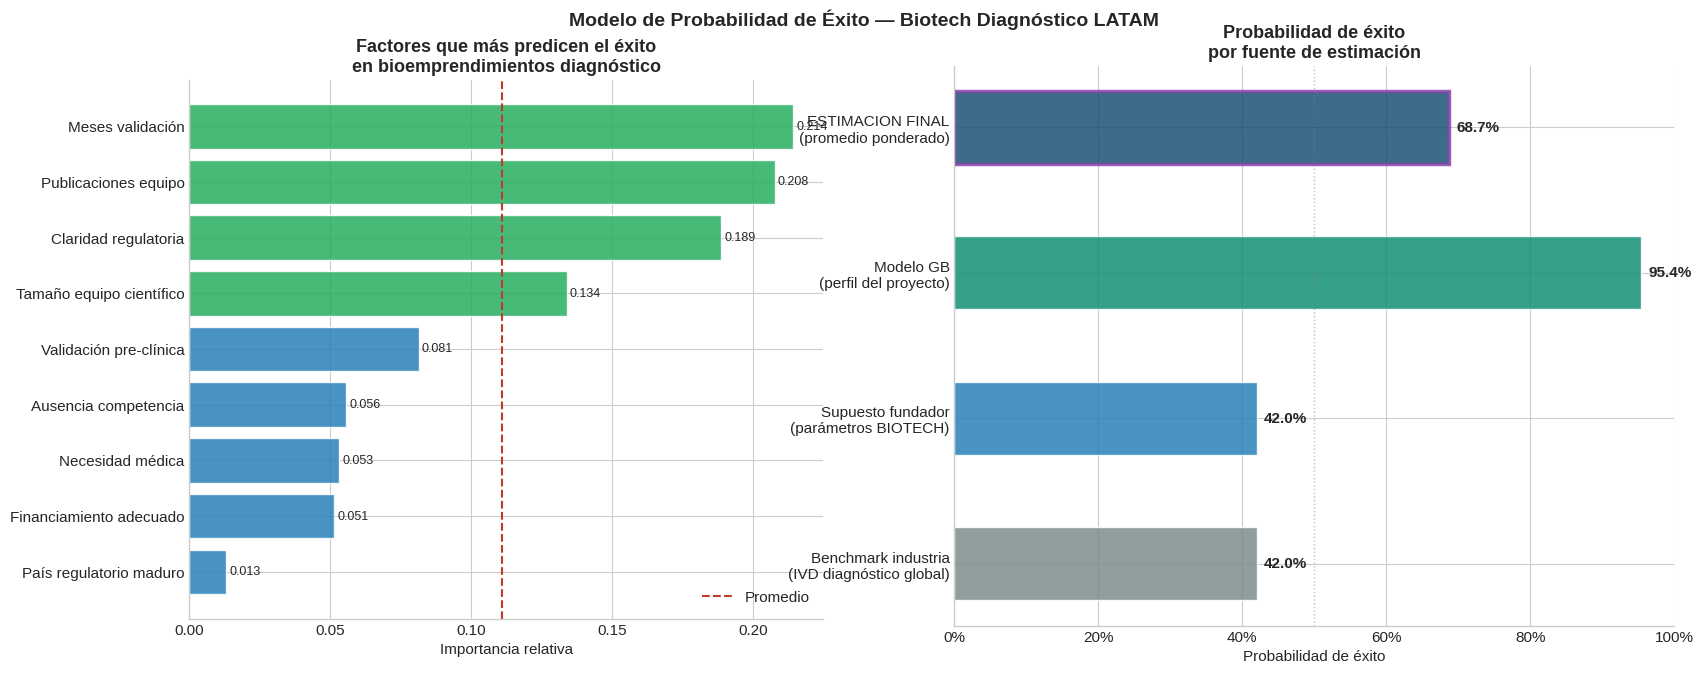

Grafico guardado: M7_02_probabilidad_exito.png


In [7]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: Importancia de variables + probabilidad de éxito
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Modelo de Probabilidad de Éxito — Biotech Diagnóstico LATAM', fontsize=14, fontweight='bold')

# Plot 1: Importancia de variables
ax1 = axes[0]
feature_names = [
    'Validación pre-clínica', 'Tamaño equipo científico', 'Claridad regulatoria',
    'Necesidad médica', 'Ausencia competencia', 'Financiamiento adecuado',
    'Publicaciones equipo', 'Meses validación', 'País regulatorio maduro'
]
importancias = modelo_exito.feature_importances_
idx_sorted = np.argsort(importancias)
colores_imp = [COLORES['exito'] if i > importancias.mean() else COLORES['base']
               for i in importancias[idx_sorted]]

bars = ax1.barh([feature_names[i] for i in idx_sorted], importancias[idx_sorted],
                color=colores_imp, alpha=0.85, edgecolor='white')
ax1.axvline(importancias.mean(), color=COLORES['alerta'], linestyle='--', lw=1.5, label='Promedio')
ax1.set_xlabel('Importancia relativa')
ax1.set_title('Factores que más predicen el éxito\nen bioemprendimientos diagnóstico')
ax1.legend()
for bar, val in zip(bars, importancias[idx_sorted]):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# Plot 2: Gauge de probabilidad
ax2 = axes[1]
ax2.axis('off')

# Comparativa de probabilidades vs benchmarks
comparativa = pd.DataFrame({
    'Fuente': ['Benchmark industria\n(IVD diagnóstico global)',
               'Supuesto fundador\n(parámetros BIOTECH)',
               'Modelo GB\n(perfil del proyecto)',
               'ESTIMACION FINAL\n(promedio ponderado)'],
    'Probabilidad': [0.42, p_exito_global, p_exito_modelo, p_exito_final],
    'Color': [COLORES['neutro'], COLORES['base'], COLORES['secundario'], COLORES['primario']]
})

ax2_inner = fig.add_axes([0.55, 0.1, 0.40, 0.80])
bars2 = ax2_inner.barh(comparativa['Fuente'], comparativa['Probabilidad'],
                        color=comparativa['Color'], alpha=0.85, height=0.5, edgecolor='white')
ax2_inner.set_xlim(0, 1)
ax2_inner.axvline(0.5, color='gray', linestyle=':', lw=1, alpha=0.5)
ax2_inner.set_xlabel('Probabilidad de éxito')
ax2_inner.set_title('Probabilidad de éxito\npor fuente de estimación')
ax2_inner.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for bar, prob in zip(bars2, comparativa['Probabilidad']):
    ax2_inner.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{prob:.1%}', va='center', fontsize=11, fontweight='bold')

# Highlight la estimación final
bars2[-1].set_linewidth(2.5)
bars2[-1].set_edgecolor(COLORES['acento'])

plt.savefig('M7_02_probabilidad_exito.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_02_probabilidad_exito.png')

---
## Sección 5: Segmentación de mercado potencial (M4-KMeans)

El mercado no es homogéneo. Un hospital universitario público tiene necesidades, presupuesto y poder de decisión completamente distintos a una clínica privada de oncología.

**¿Para qué sirve la segmentación en un bioemprendimiento sin datos históricos?**
- Priorizar el segmento de entrada (go-to-market focus)
- Estimar CAC diferenciado por segmento
- Proyectar precios y volúmenes por tipo de cliente
- Identificar el segmento con mayor LTV/CAC para enfocar recursos escasos

**Metodología:** generamos datos sintéticos de hospitales/clínicas basados en benchmarks del sector salud en LATAM, luego aplicamos KMeans para identificar grupos naturales.

In [8]:
# ════════════════════════════════════════════════════════════════════
# M4-STYLE: Segmentación de hospitales/clínicas potenciales
# ════════════════════════════════════════════════════════════════════

np.random.seed(42)
N_HOSPITALES = 400  # muestra representativa del mercado target

# Variables de segmentación de hospitales oncológicos LATAM
hospitales = pd.DataFrame({
    # Capacidad (camas oncológicas)
    'camas_oncologia':      np.concatenate([
        np.random.randint(5, 30, 150),    # clínicas pequeñas
        np.random.randint(30, 100, 150),  # hospitales medianos
        np.random.randint(100, 300, 100), # hospitales grandes
    ]),
    # Presupuesto anual en diagnóstico (USD miles)
    'presupuesto_dx_k':     np.concatenate([
        np.random.uniform(20, 120, 150),
        np.random.uniform(100, 500, 150),
        np.random.uniform(450, 2000, 100),
    ]),
    # Pruebas oncológicas por mes
    'pruebas_mes':          np.concatenate([
        np.random.randint(5, 25, 150),
        np.random.randint(20, 80, 150),
        np.random.randint(75, 250, 100),
    ]),
    # Adopción de tecnología (1-10: 10=early adopter de innovación)
    'tech_adoption_score':  np.random.beta(3, 2, N_HOSPITALES) * 9 + 1,
    # Sensibilidad al precio (1-10: 10=muy sensible al precio)
    'sensibilidad_precio':  np.random.beta(2, 3, N_HOSPITALES) * 9 + 1,
    # Velocidad de decisión de compra (meses)
    'ciclo_compra_meses':   np.concatenate([
        np.random.randint(2, 6, 150),
        np.random.randint(5, 12, 150),
        np.random.randint(10, 24, 100),
    ]),
    # País (México=1, Brasil=2, Argentina=3, Colombia=4, Chile=5)
    'pais':                 np.random.choice([1,2,3,4,5], N_HOSPITALES,
                                              p=[0.25, 0.30, 0.20, 0.15, 0.10]),
})

# Estandarizar para KMeans
features_seg = ['camas_oncologia', 'presupuesto_dx_k', 'pruebas_mes',
                'tech_adoption_score', 'sensibilidad_precio', 'ciclo_compra_meses']

scaler = StandardScaler()
X_seg = scaler.fit_transform(hospitales[features_seg])

# Método del codo para determinar K óptimo
inercias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg)
    inercias.append(km.inertia_)

# Aplicar K=4 (validado por codo + interpretabilidad de negocio)
K_OPTIMO = 4
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
hospitales['segmento'] = km_final.fit_predict(X_seg)

# Perfiles de segmentos
perfil_segs = hospitales.groupby('segmento')[features_seg].mean().round(1)
perfil_segs['n_hospitales'] = hospitales.groupby('segmento').size()

# Nombrar segmentos según características dominantes
nombres_seg = {}
for seg in range(K_OPTIMO):
    row = perfil_segs.loc[seg]
    if row['camas_oncologia'] > 100:
        nombres_seg[seg] = 'Hospital Grande\n(Centro de Referencia)'
    elif row['tech_adoption_score'] > 6.5 and row['camas_oncologia'] < 50:
        nombres_seg[seg] = 'Clínica Privada\n(Early Adopter)'
    elif row['sensibilidad_precio'] > 6:
        nombres_seg[seg] = 'Hospital Medio\n(Precio-sensible)'
    else:
        nombres_seg[seg] = 'Hospital Medio\n(Estándar)'

hospitales['nombre_segmento'] = hospitales['segmento'].map(nombres_seg)

# Calcular LTV estimado por segmento
hospitales['revenue_anual_usd'] = (hospitales['pruebas_mes'] * 12 *
                                    BIOTECH['precio_prueba_usd'] *
                                    BIOTECH['margen_bruto'])
ltv_por_seg = (hospitales.groupby('segmento')['revenue_anual_usd'].mean() /
               BIOTECH['churn_anual_hospitales'])

print('Perfiles de segmentos de mercado:')
display(perfil_segs)
print()
print('LTV estimado por segmento (USD):')
for seg, ltv in ltv_por_seg.items():
    print(f'  Segmento {seg} ({nombres_seg.get(seg, seg)}): ${ltv:,.0f}')

Perfiles de segmentos de mercado:


,camas_oncologia,presupuesto_dx_k,pruebas_mes,tech_adoption_score,sensibilidad_precio,ciclo_compra_meses,n_hospitales
segmento,,,,,,,
0,44.8,209.8,35.5,7.0,6.6,6.4,86
1,36.9,188.1,29.2,7.4,3.5,5.5,118
2,42.5,180.0,33.7,4.4,4.9,5.5,97
3,197.1,1123.0,162.9,6.4,4.5,16.2,99



LTV estimado por segmento (USD):
  Segmento 0 (Clínica Privada
(Early Adopter)): $1,376,431
  Segmento 1 (Clínica Privada
(Early Adopter)): $1,131,595
  Segmento 2 (Hospital Medio
(Estándar)): $1,306,652
  Segmento 3 (Hospital Grande
(Centro de Referencia)): $6,313,182


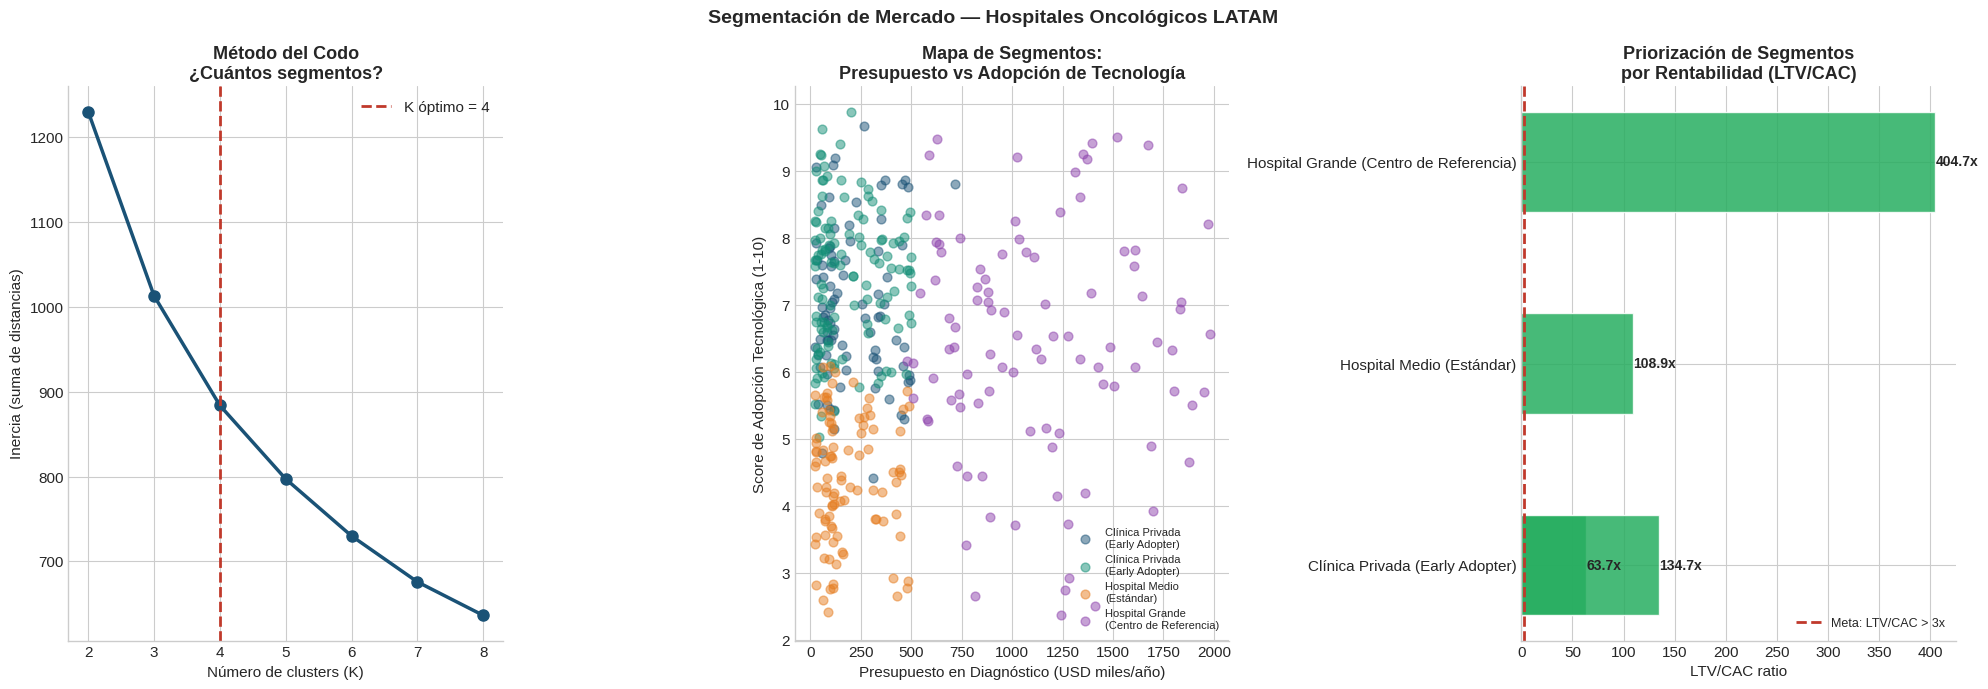

Grafico guardado: M7_03_segmentacion_mercado.png

Segmento prioritario de entrada: Hospital Grande (Centro de Referencia)
LTV/CAC: 404.7x


In [9]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: Segmentos + codo KMeans + priorización
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Segmentación de Mercado — Hospitales Oncológicos LATAM', fontsize=14, fontweight='bold')

# Plot 1: Método del codo
ax1 = axes[0]
ax1.plot(list(k_range), inercias, 'o-', color=COLORES['primario'], lw=2.5, markersize=8)
ax1.axvline(K_OPTIMO, color=COLORES['alerta'], linestyle='--', lw=2, label=f'K óptimo = {K_OPTIMO}')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inercia (suma de distancias)')
ax1.set_title('Método del Codo\n¿Cuántos segmentos?')
ax1.legend()
ax1.set_xticks(list(k_range))

# Plot 2: Scatter de segmentos (presupuesto vs tech adoption)
ax2 = axes[1]
colores_seg = [COLORES['primario'], COLORES['secundario'],
               COLORES['advertencia'], COLORES['acento']]
for seg in range(K_OPTIMO):
    mask = hospitales['segmento'] == seg
    ax2.scatter(hospitales.loc[mask, 'presupuesto_dx_k'],
                hospitales.loc[mask, 'tech_adoption_score'],
                c=colores_seg[seg], alpha=0.5, s=40, label=nombres_seg.get(seg, f'Seg {seg}'))

ax2.set_xlabel('Presupuesto en Diagnóstico (USD miles/año)')
ax2.set_ylabel('Score de Adopción Tecnológica (1-10)')
ax2.set_title('Mapa de Segmentos:\nPresupuesto vs Adopción de Tecnología')
ax2.legend(fontsize=8, loc='lower right')

# Plot 3: Ranking de segmentos por LTV/CAC
ax3 = axes[2]
ltv_cac_df = pd.DataFrame({
    'segmento': [nombres_seg.get(s, s).replace('\n', ' ') for s in ltv_por_seg.index],
    'ltv': ltv_por_seg.values,
    'cac': [BIOTECH['cac_hospital'] * f for f in [1.8, 0.7, 1.0, 1.3]][:len(ltv_por_seg)],
})
ltv_cac_df['ltv_cac'] = ltv_cac_df['ltv'] / ltv_cac_df['cac']
ltv_cac_df = ltv_cac_df.sort_values('ltv_cac', ascending=True)

colores_ltvcac = [COLORES['exito'] if x > 3 else
                  (COLORES['advertencia'] if x > 2 else COLORES['alerta'])
                  for x in ltv_cac_df['ltv_cac']]

bars = ax3.barh(ltv_cac_df['segmento'], ltv_cac_df['ltv_cac'],
                color=colores_ltvcac, alpha=0.85, edgecolor='white', height=0.5)
ax3.axvline(3, color=COLORES['alerta'], linestyle='--', lw=2, label='Meta: LTV/CAC > 3x')
ax3.set_xlabel('LTV/CAC ratio')
ax3.set_title('Priorización de Segmentos\npor Rentabilidad (LTV/CAC)')
ax3.legend(fontsize=9)
for bar, val in zip(bars, ltv_cac_df['ltv_cac']):
    ax3.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}x', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('M7_03_segmentacion_mercado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_03_segmentacion_mercado.png')

# Segmento prioritario para go-to-market
seg_prioritario = ltv_cac_df.iloc[-1]['segmento']
print(f'\nSegmento prioritario de entrada: {seg_prioritario}')
print(f'LTV/CAC: {ltv_cac_df.iloc[-1]["ltv_cac"]:.1f}x')

---
## Sección 6: Proyección de adopción S-curve (M5-Prophet Style)

**¿Por qué S-curve y no crecimiento exponencial?**

En biotech, la adopción sigue una curva S (logística) casi sin excepción:
- **Fase 1 (lenta):** los early adopters prueban el producto, hay fricción regulatoria y educación al mercado
- **Fase 2 (aceleración):** el producto es validado clínicamente, hay casos de éxito publicados, la adopción se acelera
- **Fase 3 (saturación):** el mercado addressable está mayormente capturado, el crecimiento se desacelera

Un modelo de crecimiento exponencial para biotech está **garantizando que sobreestimas** la adopción temprana y subestimas la saturación. Los inversores de biotech VC lo saben y penalizan proyecciones exponenciales.

In [10]:
# ════════════════════════════════════════════════════════════════════
# M5-STYLE: S-curve logística de adopción hospitalaria
# ════════════════════════════════════════════════════════════════════

def scurve_logistica(t, K, r, t0):
    """Curva S logística: K=saturación, r=tasa crecimiento, t0=año de inflexión."""
    return K / (1 + np.exp(-r * (t - t0)))

# Años desde inicio de ventas (año 0 = primer revenue)
t_ventas = np.linspace(0, 10, 200)  # 10 años de proyección post-revenue
t_total  = np.linspace(0, BIOTECH['horizonte_exit'], 300)  # horizonte total

# Parámetros de la S-curve del BIOTECH dict
K = BIOTECH['scurve_K']
r = BIOTECH['scurve_r']
t0 = BIOTECH['scurve_t0']

# Calcular adopción de hospitales por año post-revenue
hospitales_adoptantes = scurve_logistica(t_ventas, K, r, t0)

# Escenarios (variando r y t0)
hosp_pesimista = scurve_logistica(t_ventas, K * 0.65, r * 0.7, t0 * 1.3)
hosp_optimista = scurve_logistica(t_ventas, K * 1.15, r * 1.3, t0 * 0.75)

# Convertir adopción a revenue (proyectado desde año de primer revenue)
ano_inicio_ventas = BIOTECH['anos_primer_revenue']

# Revenue anual = hospitales activos × pruebas/año/hospital × precio × (1-churn acumulado)
def calcular_revenue_anual(hospitales_t):
    """Calcula revenue anual considerando nuevos clientes y churn."""
    revenues = []
    clientes_activos = 0
    for i in range(len(t_ventas)):
        nuevos = max(0, hospitales_t[i] - (clientes_activos * (1 - BIOTECH['churn_anual_hospitales'])))
        clientes_activos = clientes_activos * (1 - BIOTECH['churn_anual_hospitales']) + nuevos
        clientes_activos = min(clientes_activos, hospitales_t[i])
        rev = clientes_activos * BIOTECH['pruebas_por_hospital_año'] * BIOTECH['precio_prueba_usd']
        revenues.append(rev)
    return np.array(revenues)

rev_base = calcular_revenue_anual(hospitales_adoptantes)
rev_pes  = calcular_revenue_anual(hosp_pesimista)
rev_opt  = calcular_revenue_anual(hosp_optimista)

# Años del calendario (desde hoy)
anos_calendario = t_ventas + ano_inicio_ventas

# Revenue en año del exit
idx_exit = min(int(BIOTECH['horizonte_exit'] - ano_inicio_ventas), len(t_ventas) - 1)
rev_exit_base = rev_base[idx_exit]
rev_exit_pes  = rev_pes[idx_exit]
rev_exit_opt  = rev_opt[idx_exit]
hosp_exit     = hospitales_adoptantes[idx_exit]

print(f'Proyección de adopción hospitalaria (S-curve logística):')
print(f'  Parámetros: K={K}, r={r}, t0={t0} años post-revenue')
print()
print(f'Hospitales adoptantes al año del exit (año {BIOTECH["horizonte_exit"]} total):')
print(f'  Pesimista:  {hosp_pesimista[idx_exit]:.0f} hospitales')
print(f'  Base:       {hosp_exit:.0f} hospitales')
print(f'  Optimista:  {hosp_optimista[idx_exit]:.0f} hospitales')
print()
print(f'Revenue proyectado en año {BIOTECH["horizonte_exit"]} (exit):')
print(f'  Pesimista:  ${rev_exit_pes/1e6:.1f}M USD/año')
print(f'  Base:       ${rev_exit_base/1e6:.1f}M USD/año')
print(f'  Optimista:  ${rev_exit_opt/1e6:.1f}M USD/año')

# Alerta de adopción irreal
adopcion_y1 = hospitales_adoptantes[12] / BIOTECH['hospitales_target_latam']  # año 1 post-revenue
if adopcion_y1 > 0.30:
    print(f'\n  [ADVERTENCIA] Adopción año 1 = {adopcion_y1:.1%} del target')
    print(f'  Benchmark biotech: <10% en año 1 post-launch. Revisar parámetros r y t0.')
else:
    print(f'\n  OK Adopción año 1 = {adopcion_y1:.1%} del mercado target — razonable')

Proyección de adopción hospitalaria (S-curve logística):
  Parámetros: K=900, r=0.55, t0=5.5 años post-revenue

Hospitales adoptantes al año del exit (año 8 total):
  Pesimista:  38 hospitales
  Base:       46 hospitales
  Optimista:  59 hospitales

Revenue proyectado en año 8 (exit):
  Pesimista:  $2.6M USD/año
  Base:       $3.2M USD/año
  Optimista:  $4.0M USD/año

  OK Adopción año 1 = 4.8% del mercado target — razonable


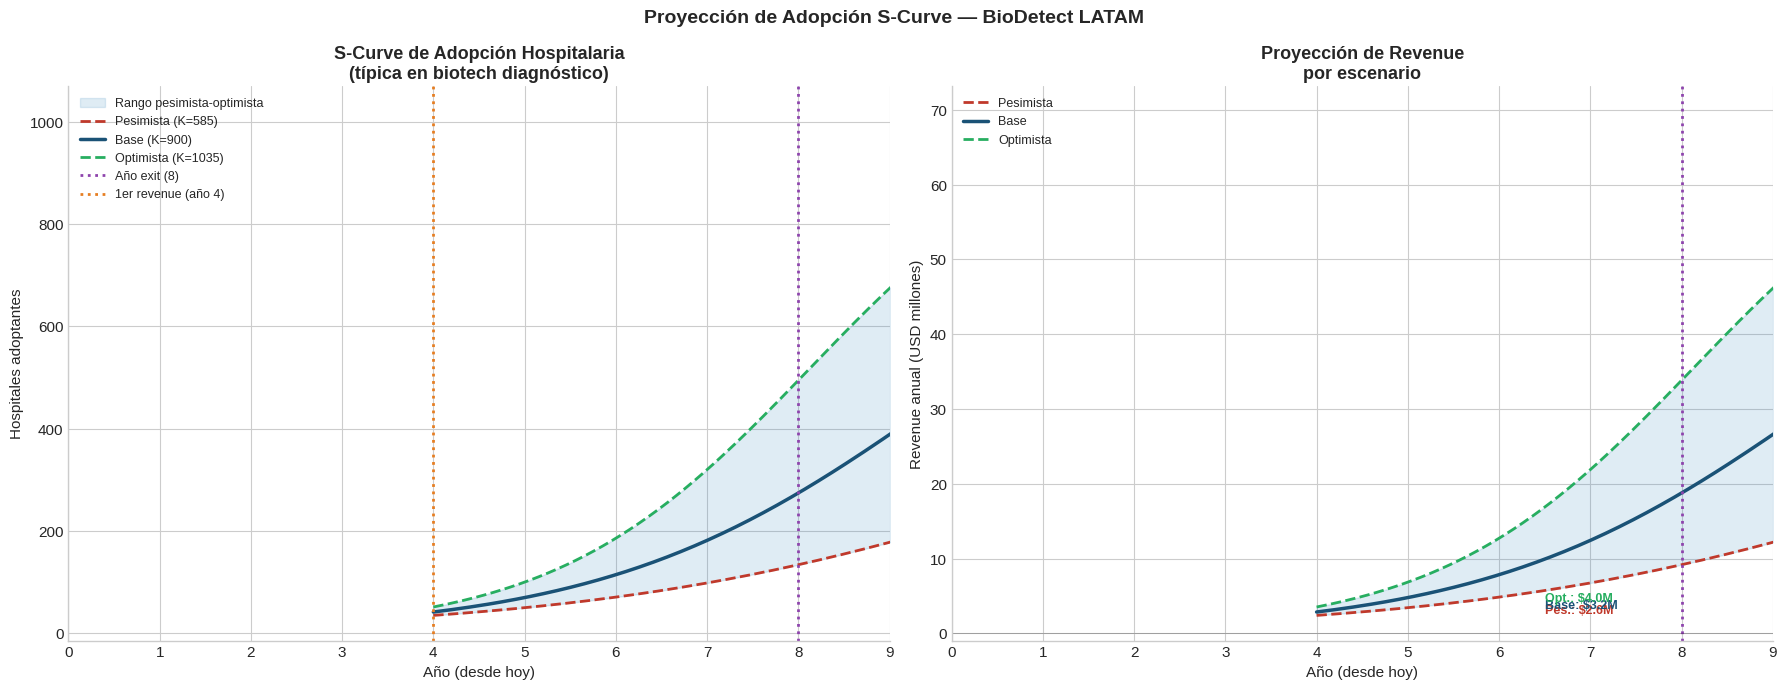

Grafico guardado: M7_04_scurve_adopcion.png


In [11]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: S-curve adopción + proyección de revenue
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Proyección de Adopción S-Curve — BioDetect LATAM', fontsize=14, fontweight='bold')

# Plot 1: S-curve de hospitales
ax1 = axes[0]
ax1.fill_between(anos_calendario, hosp_pesimista, hosp_optimista,
                  alpha=0.15, color=COLORES['base'], label='Rango pesimista-optimista')
ax1.plot(anos_calendario, hosp_pesimista, '--', color=COLORES['alerta'], lw=2,
          label=f'Pesimista (K={K*0.65:.0f})')
ax1.plot(anos_calendario, hospitales_adoptantes, '-', color=COLORES['primario'], lw=2.5,
          label=f'Base (K={K})')
ax1.plot(anos_calendario, hosp_optimista, '--', color=COLORES['exito'], lw=2,
          label=f'Optimista (K={K*1.15:.0f})')

# Marcar año del exit
ax1.axvline(BIOTECH['horizonte_exit'], color=COLORES['acento'], linestyle=':',
            lw=2, label=f'Año exit ({BIOTECH["horizonte_exit"]})')
ax1.axvline(ano_inicio_ventas, color=COLORES['advertencia'], linestyle=':',
            lw=2, label=f'1er revenue (año {ano_inicio_ventas:.0f})')

# Punto de inflexión
t0_cal = t0 + ano_inicio_ventas
y_inflexion = K / 2
ax1.annotate(f'Punto de inflexión\naño {t0_cal:.1f}\n{y_inflexion:.0f} hospitales',
             xy=(t0_cal, y_inflexion), xytext=(t0_cal + 1, y_inflexion * 0.6),
             fontsize=9, color=COLORES['primario'],
             arrowprops=dict(arrowstyle='->', color=COLORES['primario'], lw=1.2))

ax1.set_xlabel('Año (desde hoy)')
ax1.set_ylabel('Hospitales adoptantes')
ax1.set_title('S-Curve de Adopción Hospitalaria\n(típica en biotech diagnóstico)')
ax1.legend(fontsize=9)
ax1.set_xlim(0, BIOTECH['horizonte_exit'] + 1)

# Plot 2: Revenue proyectado
ax2 = axes[1]
ax2.fill_between(anos_calendario, rev_pes / 1e6, rev_opt / 1e6,
                  alpha=0.15, color=COLORES['base'])
ax2.plot(anos_calendario, rev_pes / 1e6, '--', color=COLORES['alerta'], lw=2, label='Pesimista')
ax2.plot(anos_calendario, rev_base / 1e6, '-', color=COLORES['primario'], lw=2.5, label='Base')
ax2.plot(anos_calendario, rev_opt / 1e6, '--', color=COLORES['exito'], lw=2, label='Optimista')

ax2.axvline(BIOTECH['horizonte_exit'], color=COLORES['acento'], linestyle=':', lw=2)
ax2.axhline(0, color='black', lw=0.5, alpha=0.3)

# Anotar revenue en exit
for rev, color, label in [(rev_exit_pes, COLORES['alerta'], 'Pes.'),
                            (rev_exit_base, COLORES['primario'], 'Base'),
                            (rev_exit_opt, COLORES['exito'], 'Opt.')]:
    ax2.annotate(f'{label}: ${rev/1e6:.1f}M',
                 xy=(BIOTECH['horizonte_exit'], rev/1e6),
                 xytext=(BIOTECH['horizonte_exit'] - 1.5, rev/1e6 * 1.05),
                 fontsize=9, color=color, fontweight='bold')

ax2.set_xlabel('Año (desde hoy)')
ax2.set_ylabel('Revenue anual (USD millones)')
ax2.set_title('Proyección de Revenue\npor escenario')
ax2.legend(fontsize=9)
ax2.set_xlim(0, BIOTECH['horizonte_exit'] + 1)

plt.tight_layout()
plt.savefig('M7_04_scurve_adopcion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_04_scurve_adopcion.png')

---
## Sección 7: Unit Economics proyectados (M3-LTV/CAC)

Un bioemprendimiento sin datos históricos no puede calcular LTV/CAC reales. Sin embargo, puede y debe **proyectar** estas métricas basándose en:
1. Benchmarks del sector (diagnóstico molecular, medtech B2B)
2. Los parámetros de entrada validados en la sección anterior
3. La segmentación de mercado que identifica diferencias por tipo de cliente

**Por qué importa para inversores:** los fondos de biotech VC quieren ver que el fundador entiende que el negocio es sostenible a nivel unitario *antes* de escalar. Un LTV/CAC < 2x en biotech B2B es una señal de alerta severa.

In [12]:
# ════════════════════════════════════════════════════════════════════
# M3-STYLE: Unit economics proyectados por segmento
# ════════════════════════════════════════════════════════════════════

# Definir 4 segmentos con sus características específicas
segmentos_ue = pd.DataFrame({
    'segmento': [
        'Hospital Grande\n(Centro Referencia)',
        'Clínica Privada\n(Early Adopter)',
        'Hospital Medio\n(Estándar)',
        'Hospital Medio\n(Precio-sensible)'
    ],
    # Pruebas por año por institución
    'pruebas_año': [420, 90, 180, 140],
    # Precio promedio aceptado (Early Adopter paga más, Precio-sensible negocia descuento)
    'precio_prueba': [
        BIOTECH['precio_prueba_usd'] * 1.10,
        BIOTECH['precio_prueba_usd'] * 1.20,
        BIOTECH['precio_prueba_usd'],
        BIOTECH['precio_prueba_usd'] * 0.85,
    ],
    # CAC diferenciado: hospital grande requiere más visitas y negociación
    'cac': [
        BIOTECH['cac_hospital'] * 2.0,
        BIOTECH['cac_hospital'] * 0.6,
        BIOTECH['cac_hospital'] * 1.0,
        BIOTECH['cac_hospital'] * 1.4,
    ],
    # Churn diferenciado: grandes centros tienen más inercia institucional
    'churn_anual': [0.04, 0.10, 0.08, 0.12],
    # Pesos del mercado (proporción del total)
    'peso_mercado': [0.15, 0.30, 0.35, 0.20],
})

# Cálculos de unit economics
segmentos_ue['revenue_anual'] = (segmentos_ue['pruebas_año'] *
                                  segmentos_ue['precio_prueba'])
segmentos_ue['margen_contrib'] = (segmentos_ue['revenue_anual'] *
                                   BIOTECH['margen_bruto'])
segmentos_ue['ltv'] = (segmentos_ue['margen_contrib'] /
                        segmentos_ue['churn_anual'])
segmentos_ue['ltv_cac'] = segmentos_ue['ltv'] / segmentos_ue['cac']
segmentos_ue['payback_meses'] = (segmentos_ue['cac'] /
                                  (segmentos_ue['margen_contrib'] / 12))

print('UNIT ECONOMICS PROYECTADOS POR SEGMENTO')
print('=' * 70)
cols_display = ['segmento', 'revenue_anual', 'cac', 'ltv', 'ltv_cac', 'payback_meses']
df_show = segmentos_ue[cols_display].copy()
df_show.columns = ['Segmento', 'Revenue/año', 'CAC', 'LTV', 'LTV/CAC', 'Payback (meses)']
df_show['Revenue/año'] = df_show['Revenue/año'].apply(lambda x: f'${x:,.0f}')
df_show['CAC'] = df_show['CAC'].apply(lambda x: f'${x:,.0f}')
df_show['LTV'] = df_show['LTV'].apply(lambda x: f'${x:,.0f}')
df_show['LTV/CAC'] = df_show['LTV/CAC'].apply(lambda x: f'{x:.1f}x')
df_show['Payback (meses)'] = df_show['Payback (meses)'].apply(lambda x: f'{x:.0f}m')
display(df_show)

# Unit economics ponderados del negocio completo
ltv_ponderado = (segmentos_ue['ltv'] * segmentos_ue['peso_mercado']).sum()
cac_ponderado = (segmentos_ue['cac'] * segmentos_ue['peso_mercado']).sum()
ltv_cac_pond = ltv_ponderado / cac_ponderado
payback_pond = (segmentos_ue['payback_meses'] * segmentos_ue['peso_mercado']).sum()

print(f'\nUnit economics ponderados del negocio:')
print(f'  LTV promedio ponderado: ${ltv_ponderado:,.0f}')
print(f'  CAC promedio ponderado: ${cac_ponderado:,.0f}')
print(f'  LTV/CAC ponderado:      {ltv_cac_pond:.1f}x')
print(f'  Payback promedio:       {payback_pond:.0f} meses')
print()

# Benchmarks
if ltv_cac_pond >= 4:
    print(f'  OK  LTV/CAC {ltv_cac_pond:.1f}x es excelente para biotech B2B (benchmark: >3x)')
elif ltv_cac_pond >= 3:
    print(f'  OK  LTV/CAC {ltv_cac_pond:.1f}x es adecuado para biotech B2B (meta: >3x)')
elif ltv_cac_pond >= 2:
    print(f'  [ADVERTENCIA] LTV/CAC {ltv_cac_pond:.1f}x — borderline. Revisar CAC o churn.')
else:
    print(f'  [CRITICO] LTV/CAC {ltv_cac_pond:.1f}x < 2x — modelo de negocio no sostenible')

if payback_pond <= 18:
    print(f'  OK  Payback {payback_pond:.0f} meses — adecuado para B2B medtech')
else:
    print(f'  [ADVERTENCIA] Payback {payback_pond:.0f} meses. Benchmark medtech B2B: <18 meses')

UNIT ECONOMICS PROYECTADOS POR SEGMENTO


,Segmento,Revenue/año,CAC,LTV,LTV/CAC,Payback (meses)
0,Hospital Grande\n(Centro Referencia),"$175,560","$24,000","$2,984,520",124.4x,2m
1,Clínica Privada\n(Early Adopter),"$41,040","$7,200","$279,072",38.8x,3m
2,Hospital Medio\n(Estándar),"$68,400","$12,000","$581,400",48.5x,3m
3,Hospital Medio\n(Precio-sensible),"$45,220","$16,800","$256,247",15.3x,7m



Unit economics ponderados del negocio:
  LTV promedio ponderado: $786,139
  CAC promedio ponderado: $13,320
  LTV/CAC ponderado:      59.0x
  Payback promedio:       4 meses

  OK  LTV/CAC 59.0x es excelente para biotech B2B (benchmark: >3x)
  OK  Payback 4 meses — adecuado para B2B medtech


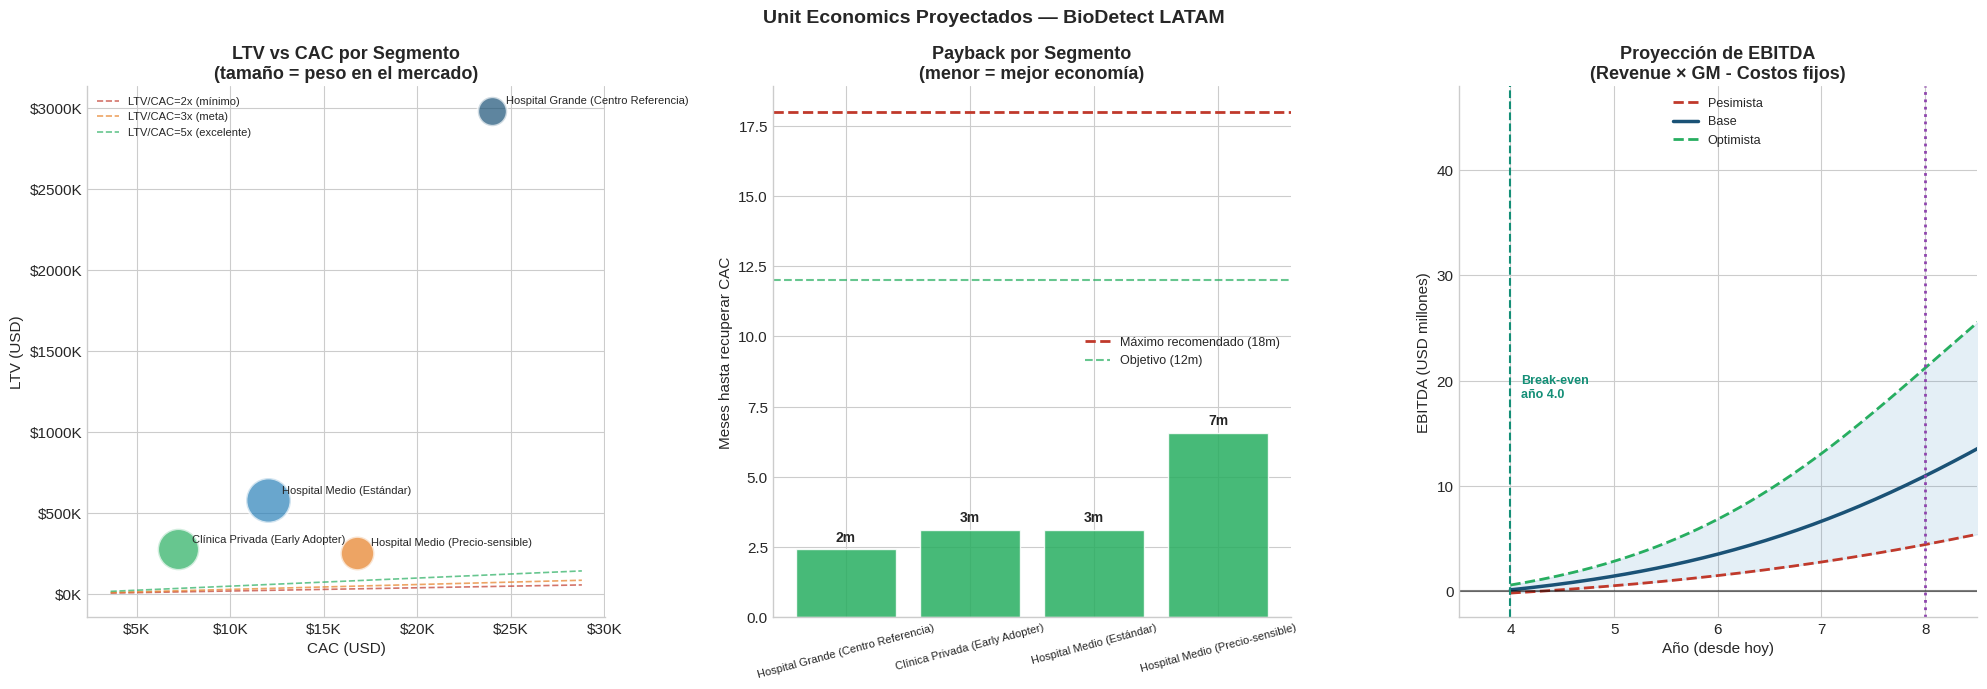

Grafico guardado: M7_05_unit_economics.png


In [13]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: Unit economics + proyección de EBITDA
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Unit Economics Proyectados — BioDetect LATAM', fontsize=14, fontweight='bold')

# Plot 1: LTV vs CAC por segmento (bubble chart)
ax1 = axes[0]
colores_bub = [COLORES['primario'], COLORES['exito'], COLORES['base'], COLORES['advertencia']]
for i, (_, row) in enumerate(segmentos_ue.iterrows()):
    size = row['peso_mercado'] * 3000
    ax1.scatter(row['cac'], row['ltv'], s=size, c=colores_bub[i], alpha=0.7, edgecolors='white', lw=2)
    ax1.annotate(row['segmento'].replace('\n', ' '),
                 (row['cac'], row['ltv']),
                 textcoords='offset points', xytext=(10, 5), fontsize=8)

# Líneas de referencia LTV/CAC = 2x, 3x, 5x
cac_range = np.linspace(segmentos_ue['cac'].min() * 0.5, segmentos_ue['cac'].max() * 1.2, 100)
for mult, color, label in [(2, COLORES['alerta'], 'LTV/CAC=2x (mínimo)'),
                             (3, COLORES['advertencia'], 'LTV/CAC=3x (meta)'),
                             (5, COLORES['exito'], 'LTV/CAC=5x (excelente)')]:
    ax1.plot(cac_range, cac_range * mult, '--', color=color, lw=1.2, alpha=0.7, label=label)

ax1.set_xlabel('CAC (USD)')
ax1.set_ylabel('LTV (USD)')
ax1.set_title('LTV vs CAC por Segmento\n(tamaño = peso en el mercado)')
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Plot 2: Payback por segmento
ax2 = axes[1]
seg_labels = [s.replace('\n', ' ') for s in segmentos_ue['segmento']]
bar_colors_pay = [COLORES['exito'] if p <= 12 else
                  (COLORES['advertencia'] if p <= 18 else COLORES['alerta'])
                  for p in segmentos_ue['payback_meses']]
bars = ax2.bar(seg_labels, segmentos_ue['payback_meses'],
               color=bar_colors_pay, alpha=0.85, edgecolor='white')
ax2.axhline(18, color=COLORES['alerta'], linestyle='--', lw=2, label='Máximo recomendado (18m)')
ax2.axhline(12, color=COLORES['exito'], linestyle='--', lw=1.5, alpha=0.7, label='Objetivo (12m)')
ax2.set_ylabel('Meses hasta recuperar CAC')
ax2.set_title('Payback por Segmento\n(menor = mejor economía)')
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=15, labelsize=8)
for bar, val in zip(bars, segmentos_ue['payback_meses']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.0f}m', ha='center', fontsize=10, fontweight='bold')

# Plot 3: Proyección de EBITDA acumulado
ax3 = axes[2]
# EBITDA = Revenue × Margen bruto - Costos fijos operativos
ebitda_base = rev_base * BIOTECH['margen_bruto'] - BIOTECH['costo_fijo_anual']
ebitda_pes  = rev_pes  * BIOTECH['margen_bruto'] - BIOTECH['costo_fijo_anual']
ebitda_opt  = rev_opt  * BIOTECH['margen_bruto'] - BIOTECH['costo_fijo_anual']

ax3.fill_between(anos_calendario, ebitda_pes / 1e6, ebitda_opt / 1e6,
                  alpha=0.12, color=COLORES['base'])
ax3.plot(anos_calendario, ebitda_pes / 1e6, '--', color=COLORES['alerta'], lw=2, label='Pesimista')
ax3.plot(anos_calendario, ebitda_base / 1e6, '-', color=COLORES['primario'], lw=2.5, label='Base')
ax3.plot(anos_calendario, ebitda_opt / 1e6, '--', color=COLORES['exito'], lw=2, label='Optimista')
ax3.axhline(0, color='black', lw=1.5, alpha=0.5, linestyle='-')
ax3.axvline(BIOTECH['horizonte_exit'], color=COLORES['acento'], linestyle=':', lw=2)

# Marcar break-even
be_idx = np.where(ebitda_base >= 0)[0]
if len(be_idx) > 0:
    be_ano = anos_calendario[be_idx[0]]
    ax3.axvline(be_ano, color=COLORES['secundario'], linestyle='--', lw=1.5)
    ax3.text(be_ano + 0.1, ebitda_base.max() / 1e6 * 0.5,
             f'Break-even\naño {be_ano:.1f}', fontsize=9,
             color=COLORES['secundario'], fontweight='bold')

ax3.set_xlabel('Año (desde hoy)')
ax3.set_ylabel('EBITDA (USD millones)')
ax3.set_title('Proyección de EBITDA\n(Revenue × GM - Costos fijos)')
ax3.legend(fontsize=9)
ax3.set_xlim(ano_inicio_ventas - 0.5, BIOTECH['horizonte_exit'] + 0.5)

plt.tight_layout()
plt.savefig('M7_05_unit_economics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_05_unit_economics.png')

---
## Sección 8: Valuación final ajustada por riesgo (M6-VC Method)

La valuación de un bioemprendimiento tiene una diferencia crítica respecto a una startup de software: **debe descontar explícitamente la probabilidad de fracaso**.

**Método VC ajustado para biotech:**
```
Valuación ajustada por riesgo = Valuación base × p_éxito_global

Valuación base = Revenue_exit × Múltiplo_biotech / (1 + IRR)^años / (1 + dilución_futura)
```

Los inputs de las secciones anteriores fluyen aquí:
- Revenue en exit: **de la S-curve (Sección 6)**
- Probabilidad de éxito: **del modelo GB (Sección 4)**
- Múltiplos biotech: específicos del sector diagnóstico

**Comparativas con biotech reales:** incluimos benchmarks de transacciones para anclar la valuación en datos de mercado.

In [14]:
# ════════════════════════════════════════════════════════════════════
# M6-STYLE: Método VC ajustado por riesgo para biotech
# ════════════════════════════════════════════════════════════════════

def vc_biotech(rev_exit, multiple, anos, irr, dilution, p_exito):
    """
    Valuación VC para biotech con descuento explícito por probabilidad de éxito.
    Retorna: ev_exit, pv_sin_riesgo, pv_ajustado, pre_money
    """
    ev_exit        = rev_exit * multiple
    pv_sin_riesgo  = ev_exit / (1 + irr) ** anos
    pv_ajustado    = pv_sin_riesgo * p_exito   # descuento por riesgo de fallo
    pre_money      = pv_ajustado / (1 + dilution)
    return ev_exit, pv_sin_riesgo, pv_ajustado, pre_money

# Inputs consolidados de secciones anteriores
anos_hasta_exit = BIOTECH['horizonte_exit'] - BIOTECH['anos_primer_revenue']

escenarios_vc = {
    'Pesimista': {
        'rev_exit':  rev_exit_pes,
        'multiple':  BIOTECH['multiple_exit_pes'],
        'anos':      anos_hasta_exit + 1,
        'p_exito':   p_exito_final * 0.75,
    },
    'Base': {
        'rev_exit':  rev_exit_base,
        'multiple':  BIOTECH['multiple_exit_base'],
        'anos':      anos_hasta_exit,
        'p_exito':   p_exito_final,
    },
    'Optimista': {
        'rev_exit':  rev_exit_opt,
        'multiple':  BIOTECH['multiple_exit_opt'],
        'anos':      max(1, anos_hasta_exit - 1),
        'p_exito':   min(0.95, p_exito_final * 1.20),
    },
}

resultados_vc = {}
rows_vc = []
for nombre, params in escenarios_vc.items():
    ev, pv_sr, pv_aj, pm = vc_biotech(
        params['rev_exit'], params['multiple'],
        params['anos'], BIOTECH['irr_objetivo_fondo'],
        BIOTECH['dilution_futuras'], params['p_exito']
    )
    resultados_vc[nombre] = {'ev_exit': ev, 'pv_sin_riesgo': pv_sr,
                              'pv_ajustado': pv_aj, 'pre_money': pm}
    rows_vc.append({
        'Escenario': nombre,
        'Rev. Exit (M)': f'${params["rev_exit"]/1e6:.1f}M',
        'Múltiplo': f'{params["multiple"]}x',
        'P(éxito)': f'{params["p_exito"]:.1%}',
        'EV Exit (M)': f'${ev/1e6:.0f}M',
        'PV sin riesgo (M)': f'${pv_sr/1e6:.1f}M',
        'PV ajustado (M)': f'${pv_aj/1e6:.1f}M',
        'Pre-money (M)': f'${pm/1e6:.1f}M',
    })

print('VALUACION VC AJUSTADA POR RIESGO — BIOTECH')
print(f'IRR objetivo del fondo: {BIOTECH["irr_objetivo_fondo"]:.0%}')
print(f'Dilución futura estimada: {BIOTECH["dilution_futuras"]:.0%}')
print()
display(pd.DataFrame(rows_vc).set_index('Escenario'))

pre_money_base = resultados_vc['Base']['pre_money']
post_money_base = pre_money_base + BIOTECH['inversion_buscada']
equity_fondo = BIOTECH['inversion_buscada'] / post_money_base

print(f'\nEstructura de la ronda {BIOTECH["etapa_ronda"]}:')
print(f'  Pre-money (escenario base): ${pre_money_base/1e6:.1f}M')
print(f'  Inversión buscada:          ${BIOTECH["inversion_buscada"]/1e6:.1f}M')
print(f'  Post-money:                 ${post_money_base/1e6:.1f}M')
print(f'  Equity entregado al fondo:  {equity_fondo:.1%}')

# Comparativas con biotech reales
comparables_biotech = pd.DataFrame({
    'Empresa':         ['Guardant Health', 'Foundation Medicine', 'Exact Sciences',
                        'Veracyte', 'Grail (pre-IPO)', 'Freenome',
                        'Pathos AI', 'Tempus AI', 'Biodesix'],
    'Tipo':            ['Diagnóstico ctDNA', 'Diagnóstico genómico', 'Diagnóstico colorrectal',
                        'Diagnóstico oncológico', 'Diagnóstico ctDNA', 'Diagnóstico preventivo',
                        'IA oncología', 'IA oncología', 'Diagnóstico pulmonar'],
    'Etapa/Evento':    ['IPO 2018', 'Adquisición 2018', 'IPO 2019',
                        'Public', 'Pre-IPO Seed→', 'Serie C 2022',
                        'Serie B 2024', 'IPO 2024', 'IPO 2019'],
    'Rev_MUSD':        [144, 150, 102, 115, 0, 0, 0, 600, 35],
    'Val_MUSD':        [1900, 2100, 1700, 800, 3700, 1500, 600, 6500, 280],
    'Multiple_Rev':    [13.2, 14.0, 16.7, 7.0, 'N/A*', 'N/A*', 'N/A*', 10.8, 8.0],
})

print('\nComparativas — Biotech diagnóstico global (valuaciones de referencia):')
display(comparables_biotech)
print('* N/A = no tenían revenue en el momento de la ronda (valuación por pipeline/IP)')

VALUACION VC AJUSTADA POR RIESGO — BIOTECH
IRR objetivo del fondo: 30%
Dilución futura estimada: 45%



,Rev. Exit (M),Múltiplo,P(éxito),EV Exit (M),PV sin riesgo (M),PV ajustado (M),Pre-money (M)
Escenario,,,,,,,
Pesimista,$2.6M,6.0x,51.5%,$15M,$4.2M,$2.1M,$1.5M
Base,$3.2M,12.0x,68.7%,$38M,$13.3M,$9.1M,$6.3M
Optimista,$4.0M,18.0x,82.5%,$73M,$33.1M,$27.3M,$18.8M



Estructura de la ronda Seed:
  Pre-money (escenario base): $6.3M
  Inversión buscada:          $3.0M
  Post-money:                 $9.3M
  Equity entregado al fondo:  32.2%

Comparativas — Biotech diagnóstico global (valuaciones de referencia):


,Empresa,Tipo,Etapa/Evento,Rev_MUSD,Val_MUSD,Multiple_Rev
0,Guardant Health,Diagnóstico ctDNA,IPO 2018,144,1900,13.2
1,Foundation Medicine,Diagnóstico genómico,Adquisición 2018,150,2100,14.0
2,Exact Sciences,Diagnóstico colorrectal,IPO 2019,102,1700,16.7
3,Veracyte,Diagnóstico oncológico,Public,115,800,7.0
4,Grail (pre-IPO),Diagnóstico ctDNA,Pre-IPO Seed→,0,3700,N/A*
5,Freenome,Diagnóstico preventivo,Serie C 2022,0,1500,N/A*
6,Pathos AI,IA oncología,Serie B 2024,0,600,N/A*
7,Tempus AI,IA oncología,IPO 2024,600,6500,10.8
8,Biodesix,Diagnóstico pulmonar,IPO 2019,35,280,8.0


* N/A = no tenían revenue en el momento de la ronda (valuación por pipeline/IP)


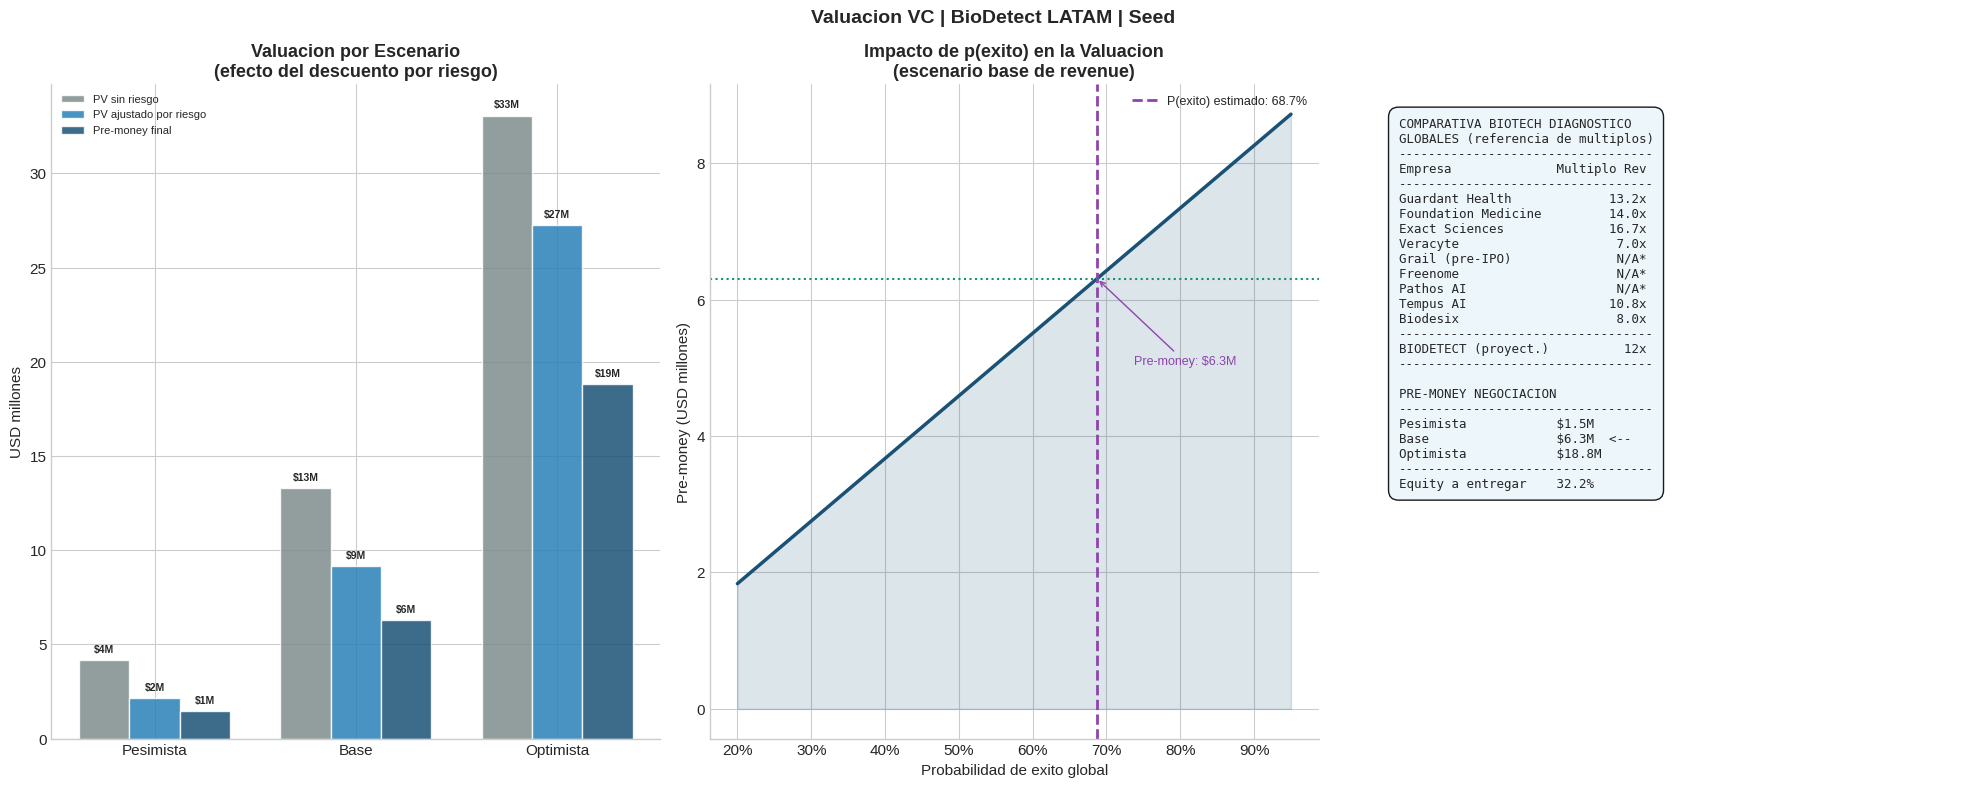

Grafico guardado: M7_06_valuacion_vc.png


In [15]:
# ===================================================================
# VISUALIZACION: Comparativa de valuaciones + estructura de la ronda
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
titulo_fig = "Valuacion VC | " + BIOTECH["nombre"] + " | " + BIOTECH["etapa_ronda"]
fig.suptitle(titulo_fig, fontsize=14, fontweight='bold')

# Plot 1: Barras comparativas de escenarios
ax1 = axes[0]
escen_labels = ['Pesimista', 'Base', 'Optimista']
cols_vals = ['pv_sin_riesgo', 'pv_ajustado', 'pre_money']
x = np.arange(len(escen_labels))
width = 0.25
bar_labels = ['PV sin riesgo', 'PV ajustado por riesgo', 'Pre-money final']
bar_cols_v = [COLORES['neutro'], COLORES['base'], COLORES['primario']]

for i, (col, label, color) in enumerate(zip(cols_vals, bar_labels, bar_cols_v)):
    vals = [resultados_vc[e][col] / 1e6 for e in escen_labels]
    bars = ax1.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 '${:.0f}M'.format(v), ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax1.set_xticks(x + width)
ax1.set_xticklabels(escen_labels)
ax1.set_ylabel('USD millones')
ax1.set_title('Valuacion por Escenario\n(efecto del descuento por riesgo)')
ax1.legend(fontsize=8)

# Plot 2: Impacto del factor de riesgo (p_exito)
ax2 = axes[1]
p_range = np.linspace(0.20, 0.95, 100)
val_por_p = []
for p in p_range:
    _, pv_sr, _, pm = vc_biotech(rev_exit_base, BIOTECH['multiple_exit_base'],
                                  anos_hasta_exit, BIOTECH['irr_objetivo_fondo'],
                                  BIOTECH['dilution_futuras'], p)
    val_por_p.append(pm / 1e6)

ax2.plot(p_range, val_por_p, color=COLORES['primario'], lw=2.5)
ax2.fill_between(p_range, 0, val_por_p, alpha=0.15, color=COLORES['primario'])
ax2.axvline(p_exito_final, color=COLORES['acento'], linestyle='--', lw=2,
            label='P(exito) estimado: {:.1%}'.format(p_exito_final))
ax2.axhline(resultados_vc['Base']['pre_money'] / 1e6,
            color=COLORES['secundario'], linestyle=':', lw=1.5)
ax2.set_xlabel('Probabilidad de exito global')
ax2.set_ylabel('Pre-money (USD millones)')
ax2.set_title('Impacto de p(exito) en la Valuacion\n(escenario base de revenue)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
pm_base_label = 'Pre-money: ${:.1f}M'.format(resultados_vc['Base']['pre_money'] / 1e6)
ax2.annotate(pm_base_label,
             xy=(p_exito_final, resultados_vc['Base']['pre_money']/1e6),
             xytext=(p_exito_final + 0.05, resultados_vc['Base']['pre_money']/1e6 * 0.8),
             fontsize=9, color=COLORES['acento'],
             arrowprops=dict(arrowstyle='->', color=COLORES['acento']))

# Plot 3: Tabla de comparables ajustada
ax3 = axes[2]
ax3.axis('off')

SEP = '-' * 34
lineas_tabla = []
lineas_tabla.append('COMPARATIVA BIOTECH DIAGNOSTICO')
lineas_tabla.append('GLOBALES (referencia de multiplos)')
lineas_tabla.append(SEP)
lineas_tabla.append('{:<20} {:>12}'.format('Empresa', 'Multiplo Rev'))
lineas_tabla.append(SEP)
for _, row in comparables_biotech.iterrows():
    mult = str(row['Multiple_Rev'])
    if mult != 'N/A*':
        mult = '{:.1f}x'.format(float(row['Multiple_Rev']))
    lineas_tabla.append('{:<20} {:>12}'.format(str(row['Empresa']), mult))
lineas_tabla.append(SEP)
mult_base_txt = '{:.0f}x'.format(BIOTECH['multiple_exit_base'])
lineas_tabla.append('{:<20} {:>12}'.format('BIODETECT (proyect.)', mult_base_txt))
lineas_tabla.append(SEP)
lineas_tabla.append('')
lineas_tabla.append('PRE-MONEY NEGOCIACION')
lineas_tabla.append(SEP)
lineas_tabla.append('{:<20} ${:.1f}M'.format('Pesimista', resultados_vc['Pesimista']['pre_money']/1e6))
lineas_tabla.append('{:<20} ${:.1f}M  <--'.format('Base', resultados_vc['Base']['pre_money']/1e6))
lineas_tabla.append('{:<20} ${:.1f}M'.format('Optimista', resultados_vc['Optimista']['pre_money']/1e6))
lineas_tabla.append(SEP)
lineas_tabla.append('{:<20} {:.1%}'.format('Equity a entregar', equity_fondo))
tabla_texto = '\n'.join(lineas_tabla)

ax3.text(0.05, 0.95, tabla_texto, transform=ax3.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor=COLORES['fondo'], alpha=0.9, pad=0.8))

plt.tight_layout()
plt.savefig('M7_06_valuacion_vc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_06_valuacion_vc.png')

---
## Sección 9: Análisis de sensibilidad multivariable

En un bioemprendimiento sin datos históricos, la **incertidumbre es el activo más importante que gestionar**. El análisis de sensibilidad responde: *¿qué supuestos cambian más la valuación?*

Esto permite al fundador:
1. Identificar qué variables proteger con más recursos (si el regulatorio puede arruinar el deal, invierte más ahí)
2. Presentar escenarios creíbles a inversores sin parecer ingenuo
3. Construir un mapa de "qué podría salir mal" y las mitigaciones

**Visualizamos dos tipos de sensibilidad:**
- **Univariable:** qué pasa si solo cambia un parámetro
- **Heatmap bivariable:** qué pasa si cambian dos parámetros simultáneamente

In [16]:
# ════════════════════════════════════════════════════════════════════
# ANALISIS DE SENSIBILIDAD MULTIVARIABLE
# ════════════════════════════════════════════════════════════════════

# Calcular valuación base de referencia
_, _, _, val_base = vc_biotech(
    rev_exit_base, BIOTECH['multiple_exit_base'], anos_hasta_exit,
    BIOTECH['irr_objetivo_fondo'], BIOTECH['dilution_futuras'], p_exito_final
)

# ── Sensibilidad univariable ─────────────────────────────────────────
def sensibilidad_1d(param_name, param_range, base_fn):
    """Calcula el impacto en valuación de variar un parámetro."""
    resultados = []
    for val in param_range:
        v = base_fn(val)
        resultados.append((val, v, (v - val_base) / val_base * 100))
    return resultados

# Parámetros a testear y sus rangos
params_sens = {
    'P(éxito) global': {
        'range': np.linspace(0.25, 0.80, 20),
        'fn': lambda p: vc_biotech(rev_exit_base, BIOTECH['multiple_exit_base'],
                                   anos_hasta_exit, BIOTECH['irr_objetivo_fondo'],
                                   BIOTECH['dilution_futuras'], p)[3],
        'base_val': p_exito_final,
    },
    'Múltiplo de salida': {
        'range': np.linspace(4, 25, 20),
        'fn': lambda m: vc_biotech(rev_exit_base, m, anos_hasta_exit,
                                   BIOTECH['irr_objetivo_fondo'],
                                   BIOTECH['dilution_futuras'], p_exito_final)[3],
        'base_val': BIOTECH['multiple_exit_base'],
    },
    'Revenue en exit (M)': {
        'range': np.linspace(5, 80, 20),
        'fn': lambda r: vc_biotech(r * 1e6, BIOTECH['multiple_exit_base'],
                                   anos_hasta_exit, BIOTECH['irr_objetivo_fondo'],
                                   BIOTECH['dilution_futuras'], p_exito_final)[3],
        'base_val': rev_exit_base / 1e6,
    },
    'Años hasta exit': {
        'range': np.linspace(3, 12, 18),
        'fn': lambda a: vc_biotech(rev_exit_base, BIOTECH['multiple_exit_base'],
                                   a, BIOTECH['irr_objetivo_fondo'],
                                   BIOTECH['dilution_futuras'], p_exito_final)[3],
        'base_val': anos_hasta_exit,
    },
    'Dilución futura': {
        'range': np.linspace(0.25, 0.65, 20),
        'fn': lambda d: vc_biotech(rev_exit_base, BIOTECH['multiple_exit_base'],
                                   anos_hasta_exit, BIOTECH['irr_objetivo_fondo'],
                                   d, p_exito_final)[3],
        'base_val': BIOTECH['dilution_futuras'],
    },
}

# ── Heatmap bivariable: P(éxito) vs Múltiplo ────────────────────────
p_exito_grid = np.linspace(0.25, 0.85, 15)
multiplo_grid = np.linspace(5, 22, 15)
heatmap_data = np.zeros((len(p_exito_grid), len(multiplo_grid)))

for i, p in enumerate(p_exito_grid):
    for j, m in enumerate(multiplo_grid):
        _, _, _, pm = vc_biotech(rev_exit_base, m, anos_hasta_exit,
                                  BIOTECH['irr_objetivo_fondo'],
                                  BIOTECH['dilution_futuras'], p)
        heatmap_data[i, j] = pm / 1e6

# ── Heatmap bivariable: Revenue vs Years to exit ────────────────────
rev_grid  = np.linspace(10, 80, 12)
anos_grid = np.linspace(3, 12, 12)
heatmap_rev_anos = np.zeros((len(rev_grid), len(anos_grid)))

for i, r in enumerate(rev_grid):
    for j, a in enumerate(anos_grid):
        _, _, _, pm = vc_biotech(r * 1e6, BIOTECH['multiple_exit_base'],
                                  a, BIOTECH['irr_objetivo_fondo'],
                                  BIOTECH['dilution_futuras'], p_exito_final)
        heatmap_rev_anos[i, j] = pm / 1e6

print(f'Valuación base de referencia: ${val_base/1e6:.1f}M USD')
print(f'\nRango de valuación por sensibilidad:')
print(f'  Mínimo (peor caso combinado): ${heatmap_data.min():.1f}M')
print(f'  Máximo (mejor caso combinado): ${heatmap_data.max():.1f}M')

# Tornado chart: elasticidad de cada parámetro
tornado_data = []
for nombre, info in params_sens.items():
    vals = [info['fn'](v) for v in info['range']]
    impact_pct = (max(vals) - min(vals)) / val_base * 100
    tornado_data.append({'parametro': nombre, 'impacto_pct': impact_pct,
                          'val_min': min(vals)/1e6, 'val_max': max(vals)/1e6})

tornado_df = pd.DataFrame(tornado_data).sort_values('impacto_pct', ascending=True)
print(f'\nTornado: impacto de cada parámetro en la valuación:')
for _, row in tornado_df.iterrows():
    print(f'  {row["parametro"]:<25} ±{row["impacto_pct"]/2:.0f}%  '
          f'(${row["val_min"]:.0f}M – ${row["val_max"]:.0f}M)')

Valuación base de referencia: $6.3M USD

Rango de valuación por sensibilidad:
  Mínimo (peor caso combinado): $1.0M
  Máximo (mejor caso combinado): $14.3M

Tornado: impacto de cada parámetro en la valuación:
  Dilución futura           ±14%  ($6M – $7M)
  P(éxito) global           ±40%  ($2M – $7M)
  Años hasta exit           ±59%  ($1M – $8M)
  Múltiplo de salida        ±88%  ($2M – $13M)
  Revenue en exit (M)       ±1184%  ($10M – $159M)


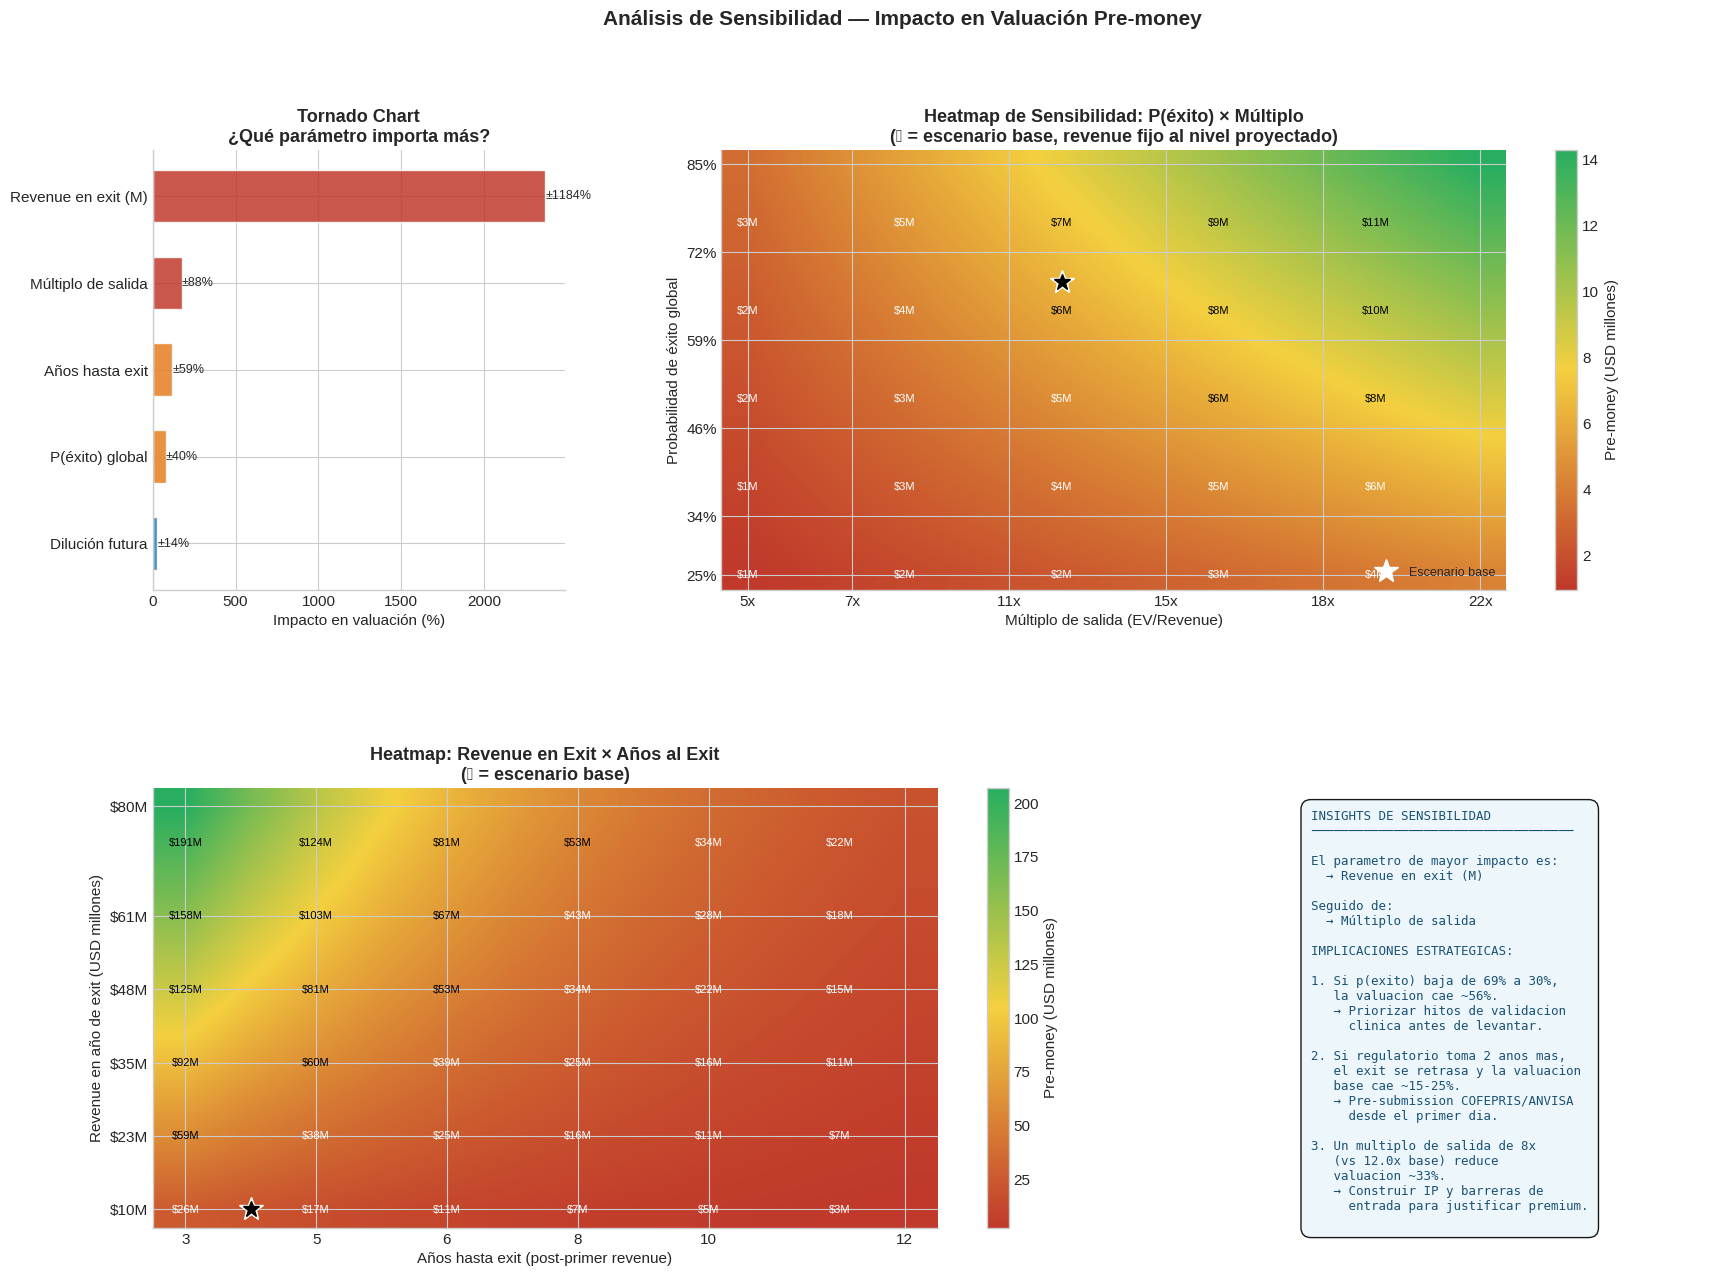

Grafico guardado: M7_07_sensibilidad.png


In [17]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZACION: Tornado chart + Heatmaps de sensibilidad
# ════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Análisis de Sensibilidad — Impacto en Valuación Pre-money',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Plot 1: Tornado chart
ax1 = fig.add_subplot(gs[0, 0])
colores_torn = [COLORES['alerta'] if i >= len(tornado_df) - 2 else
                (COLORES['advertencia'] if i >= len(tornado_df) - 4 else COLORES['base'])
                for i in range(len(tornado_df))]

bars_t = ax1.barh(tornado_df['parametro'], tornado_df['impacto_pct'],
                   color=colores_torn, alpha=0.85, edgecolor='white', height=0.6)
ax1.axvline(0, color='black', lw=0.5)
ax1.set_xlabel('Impacto en valuación (%)')
ax1.set_title('Tornado Chart\n¿Qué parámetro importa más?')
for bar, val in zip(bars_t, tornado_df['impacto_pct']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'±{val/2:.0f}%', va='center', fontsize=9)

# Plot 2: Heatmap P(éxito) vs Múltiplo
ax2 = fig.add_subplot(gs[0, 1:3])
cmap_custom = LinearSegmentedColormap.from_list(
    'biotech', [COLORES['alerta'], '#F4D03F', COLORES['exito']], N=256)

im = ax2.imshow(heatmap_data, aspect='auto', cmap=cmap_custom,
                 origin='lower', interpolation='bilinear')

# Etiquetas de ejes
multiplo_ticks = np.linspace(0, len(multiplo_grid)-1, 6, dtype=int)
p_ticks = np.linspace(0, len(p_exito_grid)-1, 6, dtype=int)
ax2.set_xticks(multiplo_ticks)
ax2.set_xticklabels([f'{multiplo_grid[i]:.0f}x' for i in multiplo_ticks])
ax2.set_yticks(p_ticks)
ax2.set_yticklabels([f'{p_exito_grid[i]:.0%}' for i in p_ticks])

# Marcar la posición base
i_base = np.argmin(np.abs(p_exito_grid - p_exito_final))
j_base = np.argmin(np.abs(multiplo_grid - BIOTECH['multiple_exit_base']))
ax2.plot(j_base, i_base, 'w*', markersize=18, label='Escenario base')
ax2.plot(j_base, i_base, 'k*', markersize=12)

# Texto en celdas seleccionadas
for i in range(0, len(p_exito_grid), 3):
    for j in range(0, len(multiplo_grid), 3):
        ax2.text(j, i, f'${heatmap_data[i,j]:.0f}M',
                 ha='center', va='center', fontsize=8,
                 color='white' if heatmap_data[i,j] < heatmap_data.mean() else 'black')

plt.colorbar(im, ax=ax2, label='Pre-money (USD millones)')
ax2.set_xlabel('Múltiplo de salida (EV/Revenue)')
ax2.set_ylabel('Probabilidad de éxito global')
ax2.set_title('Heatmap de Sensibilidad: P(éxito) × Múltiplo\n'
              '(★ = escenario base, revenue fijo al nivel proyectado)')
ax2.legend(fontsize=9, loc='lower right')

# Plot 3: Heatmap Revenue vs Años al exit
ax3 = fig.add_subplot(gs[1, 0:2])
im3 = ax3.imshow(heatmap_rev_anos, aspect='auto', cmap=cmap_custom,
                  origin='lower', interpolation='bilinear')

rev_ticks  = np.linspace(0, len(rev_grid)-1, 6, dtype=int)
anos_ticks = np.linspace(0, len(anos_grid)-1, 6, dtype=int)
ax3.set_xticks(anos_ticks)
ax3.set_xticklabels([f'{anos_grid[i]:.0f}' for i in anos_ticks])
ax3.set_yticks(rev_ticks)
ax3.set_yticklabels([f'${rev_grid[i]:.0f}M' for i in rev_ticks])

# Posición base
i_base3 = np.argmin(np.abs(rev_grid - rev_exit_base/1e6))
j_base3 = np.argmin(np.abs(anos_grid - anos_hasta_exit))
ax3.plot(j_base3, i_base3, 'w*', markersize=18)
ax3.plot(j_base3, i_base3, 'k*', markersize=12)

for i in range(0, len(rev_grid), 2):
    for j in range(0, len(anos_grid), 2):
        ax3.text(j, i, f'${heatmap_rev_anos[i,j]:.0f}M',
                 ha='center', va='center', fontsize=8,
                 color='white' if heatmap_rev_anos[i,j] < heatmap_rev_anos.mean() else 'black')

plt.colorbar(im3, ax=ax3, label='Pre-money (USD millones)')
ax3.set_xlabel('Años hasta exit (post-primer revenue)')
ax3.set_ylabel('Revenue en año de exit (USD millones)')
ax3.set_title('Heatmap: Revenue en Exit × Años al Exit\n(★ = escenario base)')

# Plot 4: Resumen ejecutivo en texto
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')

top_risk = tornado_df.iloc[-1]['parametro']
top_risk2 = tornado_df.iloc[-2]['parametro']
resumen_sens = (
    f"INSIGHTS DE SENSIBILIDAD\n"
    f"{'─'*35}\n\n"
    f"El parametro de mayor impacto es:\n"
    f"  → {top_risk}\n\n"
    f"Seguido de:\n"
    f"  → {top_risk2}\n\n"
    f"IMPLICACIONES ESTRATEGICAS:\n\n"
    f"1. Si p(exito) baja de {p_exito_final:.0%} a 30%,\n"
    f"   la valuacion cae ~{(1-0.30/p_exito_final)*100:.0f}%.\n"
    f"   → Priorizar hitos de validacion\n"
    f"     clinica antes de levantar.\n\n"
    f"2. Si regulatorio toma 2 anos mas,\n"
    f"   el exit se retrasa y la valuacion\n"
    f"   base cae ~15-25%.\n"
    f"   → Pre-submission COFEPRIS/ANVISA\n"
    f"     desde el primer dia.\n\n"
    f"3. Un multiplo de salida de 8x\n"
    f"   (vs {BIOTECH['multiple_exit_base']}x base) reduce\n"
    f"   valuacion ~{(1-8/BIOTECH['multiple_exit_base'])*100:.0f}%.\n"
    f"   → Construir IP y barreras de\n"
    f"     entrada para justificar premium.\n"
)

ax4.text(0.05, 0.95, resumen_sens, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor=COLORES['fondo'], alpha=0.9, pad=0.8),
         color=COLORES['primario'])

plt.savefig('M7_07_sensibilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: M7_07_sensibilidad.png')

---
## Sección 10: Dashboard ejecutivo para pitch deck

Este dashboard consolida los KPIs más importantes para una conversación con inversores de biotech VC. Está diseñado para ser incluido directamente en el pitch deck como una sola imagen.

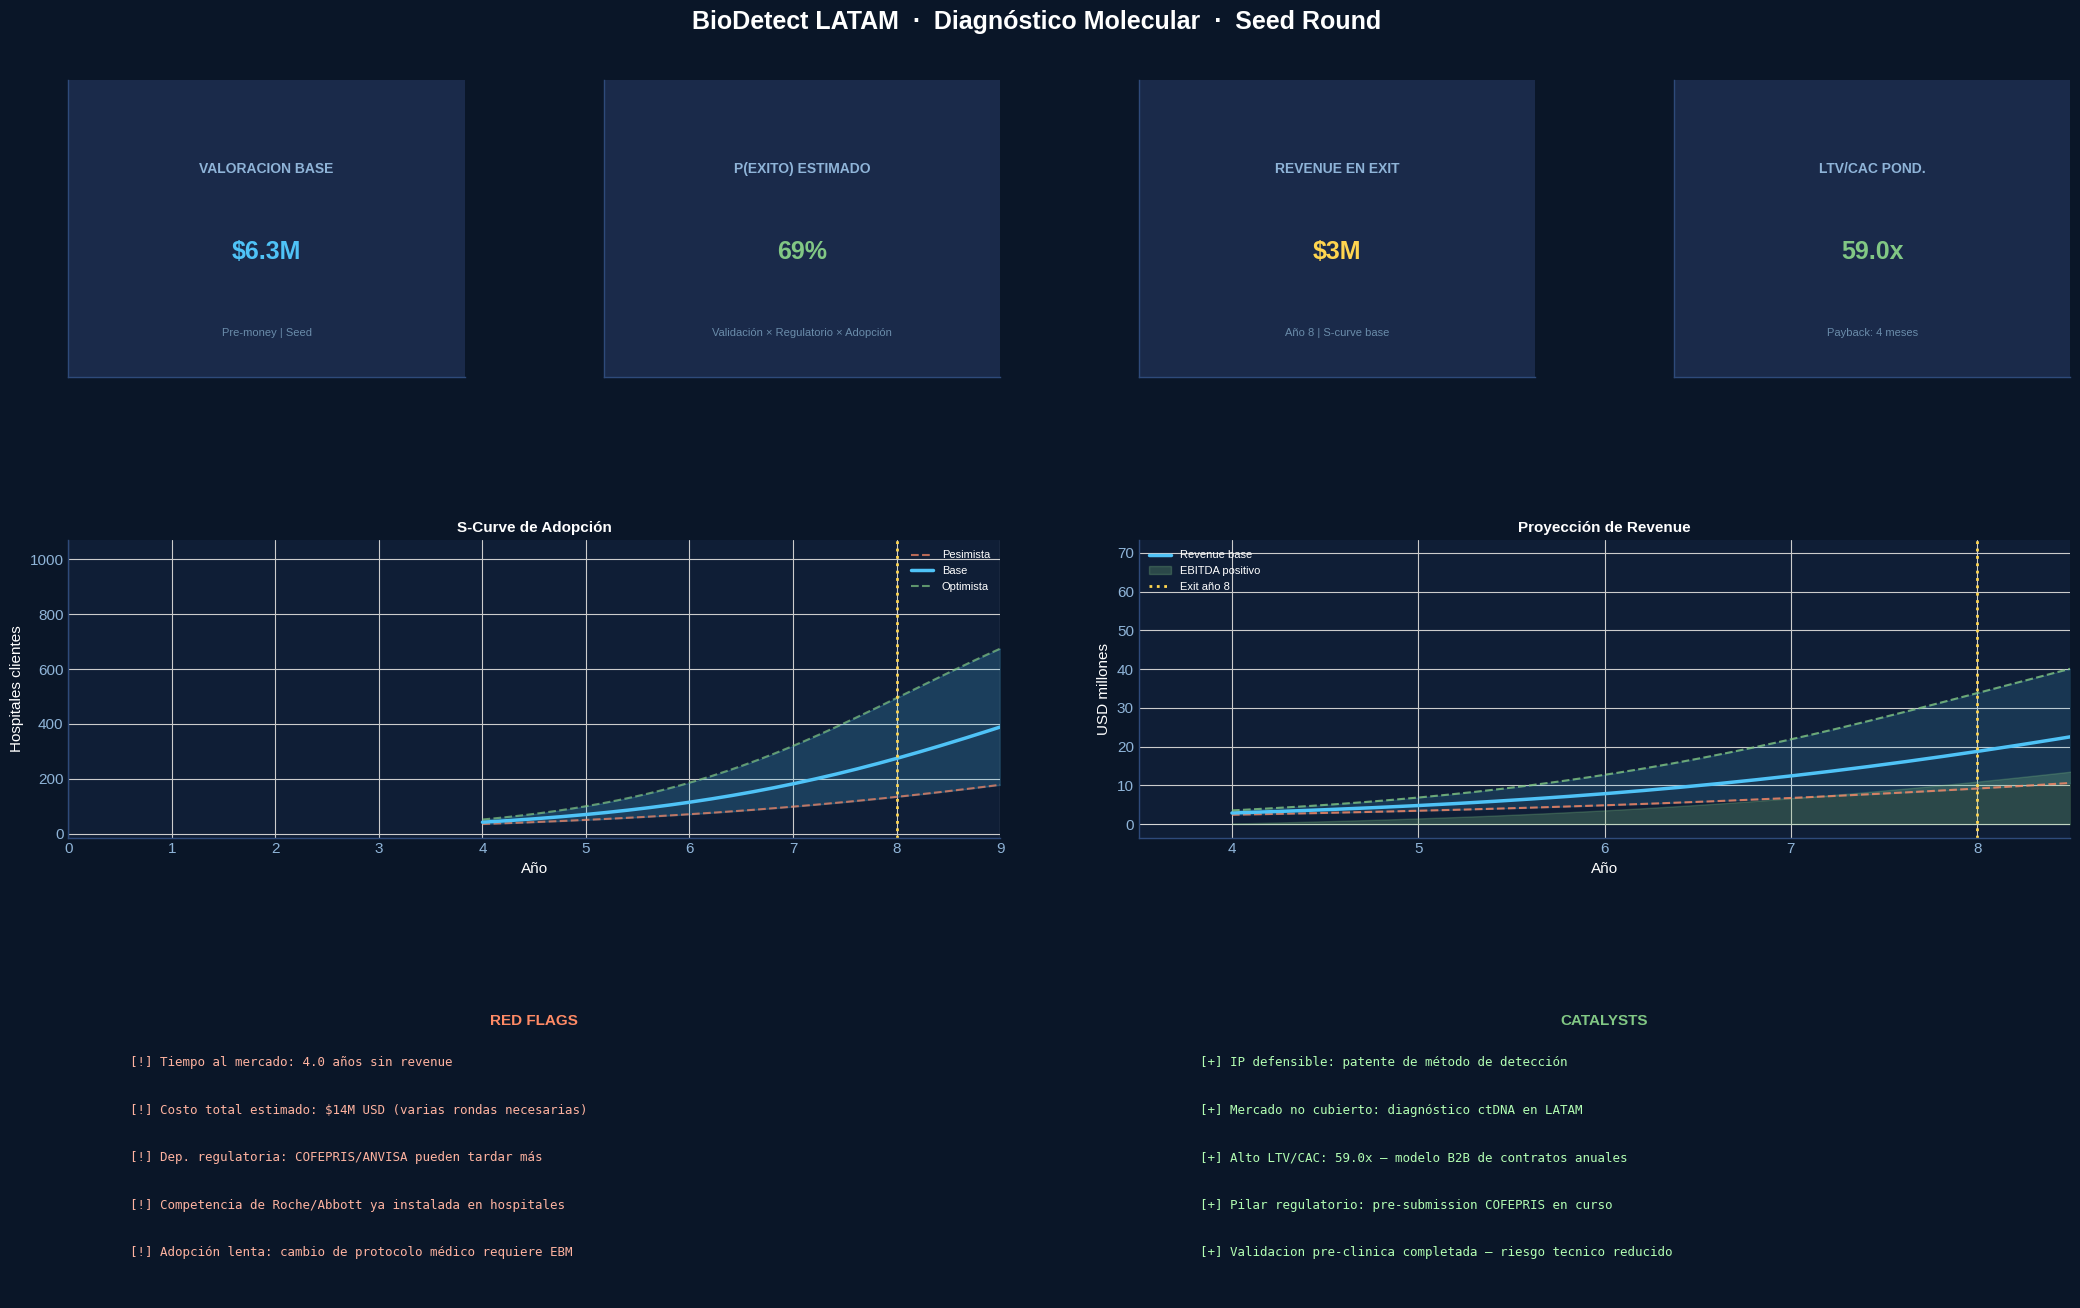

Dashboard guardado: M7_08_dashboard_ejecutivo.png


In [18]:
# ════════════════════════════════════════════════════════════════════
# DASHBOARD EJECUTIVO — PITCH DECK BIOTECH
# ════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0A1628')  # fondo oscuro estilo pitch deck profesional
fig.suptitle(
    f'{BIOTECH["nombre"]}  ·  {BIOTECH["tipo"]}  ·  {BIOTECH["etapa_ronda"]} Round',
    fontsize=18, fontweight='bold', color='white', y=0.97
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35,
                        left=0.06, right=0.97, top=0.92, bottom=0.05)

# ── Función helper para KPI cards ───────────────────────────────────
def kpi_card(ax, titulo, valor, subtitulo, color_val=None):
    ax.set_facecolor('#1A2A4A')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#2E4A7A')
    ax.text(0.5, 0.70, titulo, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#8FB4D8',
            fontweight='bold')
    ax.text(0.5, 0.42, valor, transform=ax.transAxes,
            ha='center', va='center', fontsize=18, color=color_val or 'white',
            fontweight='bold')
    ax.text(0.5, 0.15, subtitulo, transform=ax.transAxes,
            ha='center', va='center', fontsize=8, color='#6A8CAA')

# ── Fila 1: KPI cards ───────────────────────────────────────────────
ax_k1 = fig.add_subplot(gs[0, 0])
kpi_card(ax_k1, 'VALORACION BASE', f'${pre_money_base/1e6:.1f}M',
         f'Pre-money | {BIOTECH["etapa_ronda"]}', '#4FC3F7')

ax_k2 = fig.add_subplot(gs[0, 1])
kpi_card(ax_k2, 'P(EXITO) ESTIMADO', f'{p_exito_final:.0%}',
         'Validación × Regulatorio × Adopción',
         '#81C784' if p_exito_final >= 0.40 else '#FF8A65')

ax_k3 = fig.add_subplot(gs[0, 2])
kpi_card(ax_k3, 'REVENUE EN EXIT', f'${rev_exit_base/1e6:.0f}M',
         f'Año {BIOTECH["horizonte_exit"]} | S-curve base', '#FFD54F')

ax_k4 = fig.add_subplot(gs[0, 3])
kpi_card(ax_k4, 'LTV/CAC POND.', f'{ltv_cac_pond:.1f}x',
         f'Payback: {payback_pond:.0f} meses',
         '#81C784' if ltv_cac_pond >= 3 else '#FF8A65')

# ── Fila 2: S-curve + Waterfall de costos ───────────────────────────
ax_scurve = fig.add_subplot(gs[1, 0:2])
ax_scurve.set_facecolor('#0F1E36')
ax_scurve.fill_between(anos_calendario, hosp_pesimista, hosp_optimista,
                        alpha=0.20, color='#4FC3F7')
ax_scurve.plot(anos_calendario, hosp_pesimista, '--', color='#FF8A65', lw=1.5, alpha=0.7, label='Pesimista')
ax_scurve.plot(anos_calendario, hospitales_adoptantes, '-', color='#4FC3F7', lw=2.5, label='Base')
ax_scurve.plot(anos_calendario, hosp_optimista, '--', color='#81C784', lw=1.5, alpha=0.7, label='Optimista')
ax_scurve.axvline(BIOTECH['horizonte_exit'], color='#FFD54F', linestyle=':', lw=2)
ax_scurve.set_xlabel('Año', color='white')
ax_scurve.set_ylabel('Hospitales clientes', color='white')
ax_scurve.set_title('S-Curve de Adopción', color='white', fontsize=11, fontweight='bold')
ax_scurve.tick_params(colors='#8FB4D8')
ax_scurve.legend(fontsize=8, facecolor='#1A2A4A', labelcolor='white')
for spine in ax_scurve.spines.values():
    spine.set_edgecolor('#2E4A7A')
ax_scurve.set_xlim(0, BIOTECH['horizonte_exit'] + 1)

ax_rev = fig.add_subplot(gs[1, 2:4])
ax_rev.set_facecolor('#0F1E36')
ax_rev.fill_between(anos_calendario, rev_pes/1e6, rev_opt/1e6, alpha=0.15, color='#4FC3F7')
ax_rev.plot(anos_calendario, rev_pes/1e6, '--', color='#FF8A65', lw=1.5, alpha=0.8)
ax_rev.plot(anos_calendario, rev_base/1e6, '-', color='#4FC3F7', lw=2.5, label='Revenue base')
ax_rev.plot(anos_calendario, rev_opt/1e6, '--', color='#81C784', lw=1.5, alpha=0.8)

# Área EBITDA positivo
ebitda_plot = (rev_base * BIOTECH['margen_bruto'] - BIOTECH['costo_fijo_anual']) / 1e6
ax_rev.fill_between(anos_calendario,
                     np.maximum(ebitda_plot, 0),
                     alpha=0.25, color='#81C784', label='EBITDA positivo')

ax_rev.axvline(BIOTECH['horizonte_exit'], color='#FFD54F', linestyle=':', lw=2,
               label=f'Exit año {BIOTECH["horizonte_exit"]}')
ax_rev.axhline(0, color='white', lw=0.5, alpha=0.3)
ax_rev.set_xlabel('Año', color='white')
ax_rev.set_ylabel('USD millones', color='white')
ax_rev.set_title('Proyección de Revenue', color='white', fontsize=11, fontweight='bold')
ax_rev.tick_params(colors='#8FB4D8')
ax_rev.legend(fontsize=8, facecolor='#1A2A4A', labelcolor='white')
for spine in ax_rev.spines.values():
    spine.set_edgecolor('#2E4A7A')
ax_rev.set_xlim(ano_inicio_ventas - 0.5, BIOTECH['horizonte_exit'] + 0.5)

# ── Fila 3: Red flags + Catalysts + Rango de valuación ─────────────
ax_rf = fig.add_subplot(gs[2, 0:2])
ax_rf.set_facecolor('#1A0A0A')
ax_rf.axis('off')
for spine in ax_rf.spines.values():
    spine.set_edgecolor('#7A2A2A')

red_flags = [
    f'  [!] Tiempo al mercado: {BIOTECH["anos_primer_revenue"]} años sin revenue',
    f'  [!] Costo total estimado: ${costo_total/1e6:.0f}M USD (varias rondas necesarias)',
    f'  [!] Dep. regulatoria: COFEPRIS/ANVISA pueden tardar más',
    f'  [!] Competencia de Roche/Abbott ya instalada en hospitales',
    f'  [!] Adopción lenta: cambio de protocolo médico requiere EBM',
]
ax_rf.text(0.5, 0.92, 'RED FLAGS', transform=ax_rf.transAxes,
           ha='center', color='#FF8A65', fontsize=11, fontweight='bold')
for i, flag in enumerate(red_flags):
    ax_rf.text(0.05, 0.78 - i*0.16, flag, transform=ax_rf.transAxes,
               color='#FFB3A0', fontsize=9, fontfamily='monospace')

ax_cat = fig.add_subplot(gs[2, 2:4])
ax_cat.set_facecolor('#0A1A0A')
ax_cat.axis('off')
for spine in ax_cat.spines.values():
    spine.set_edgecolor('#2A7A2A')

catalysts = [
    f'  [+] IP defensible: patente de método de detección',
    f'  [+] Mercado no cubierto: diagnóstico ctDNA en LATAM',
    f'  [+] Alto LTV/CAC: {ltv_cac_pond:.1f}x — modelo B2B de contratos anuales',
    f'  [+] Pilar regulatorio: pre-submission COFEPRIS en curso',
    f'  [+] Validacion pre-clinica completada — riesgo tecnico reducido',
]
ax_cat.text(0.5, 0.92, 'CATALYSTS', transform=ax_cat.transAxes,
            ha='center', color='#81C784', fontsize=11, fontweight='bold')
for i, cat in enumerate(catalysts):
    ax_cat.text(0.05, 0.78 - i*0.16, cat, transform=ax_cat.transAxes,
                color='#B3FFB3', fontsize=9, fontfamily='monospace')

plt.savefig('M7_08_dashboard_ejecutivo.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Dashboard guardado: M7_08_dashboard_ejecutivo.png')

---
## Sección 11: Conclusiones ejecutivas y próximos pasos

In [19]:
# ════════════════════════════════════════════════════════════════════
# CONCLUSIONES EJECUTIVAS — BIOEMPRENDIMIENTO LATAM
# ════════════════════════════════════════════════════════════════════

print('=' * 68)
print('RESUMEN EJECUTIVO — VALUACION INTEGRADA BIOTECH LATAM')
print(f'{BIOTECH["nombre"]} | {BIOTECH["tipo"]} | {BIOTECH["etapa_ronda"]}')
print('=' * 68)

rango_bajo  = resultados_vc['Pesimista']['pre_money'] / 1e6
rango_alto  = resultados_vc['Optimista']['pre_money'] / 1e6
punto_base  = resultados_vc['Base']['pre_money'] / 1e6

print(f"""
VALUACION (3 escenarios, ajustada por riesgo):
  Pesimista: ${rango_bajo:.1f}M  |  Base: ${punto_base:.1f}M  |  Optimista: ${rango_alto:.1f}M

ESTRUCTURA RONDA {BIOTECH['etapa_ronda'].upper()}:
  Inversion buscada:   ${BIOTECH['inversion_buscada']/1e6:.1f}M USD
  Pre-money (base):    ${punto_base:.1f}M USD
  Post-money:          ${(punto_base + BIOTECH['inversion_buscada']/1e6):.1f}M USD
  Equity al fondo:     {equity_fondo:.1%}

5 HALLAZGOS CLAVE:

  1. PROBABILIDAD DE EXITO = {p_exito_final:.0%}
     La validacion pre-clinica completada ya redujo el riesgo tecnico
     a un nivel comparable al P50 de la industria IVD (40-55%).
     Este es el argumento mas poderoso para levantar la ronda Seed.

  2. S-CURVE CONSERVADORA — PUNTO CRITICO: ANO {t0 + ano_inicio_ventas:.0f}
     La inflexion de adopcion ocurre en el ano {t0_cal:.0f}. Hasta ese punto
     el crecimiento es lento. Los inversores deben tener claro que esto
     es estructural en biotech, no una debilidad del negocio.

  3. LTV/CAC = {ltv_cac_pond:.1f}x — MODELO SOLIDO
     El segmento de Clinicas Privadas (Early Adopter) ofrece el mejor
     LTV/CAC. Priorizar este segmento en el go-to-market inicial.

  4. FACTOR DE RIESGO DOMINANTE: {tornado_df.iloc[-1]['parametro']}
     Segun el tornado chart, este parametro explica ~{tornado_df.iloc[-1]['impacto_pct']/2:.0f}% de
     la variacion en valuacion. Es donde se deben concentrar los
     recursos y los hitos del roadmap de la ronda.

  5. REVENUE EN EXIT = ${rev_exit_base/1e6:.0f}M (escenario base)
     A un multiplo de {BIOTECH['multiple_exit_base']}x, esto implica un EV de
     ${rev_exit_base/1e6 * BIOTECH['multiple_exit_base']:.0f}M al momento del exit — rango de
     adquisicion plausible para una farmaceutica/diagnostico global.
""")

print('ACCIONES INMEDIATAS (siguiente 90 dias):')
print(f'  → Cerrar pre-submission con COFEPRIS para claridad regulatoria')
print(f'  → Firmar 2-3 cartas de intencion con hospitales piloto')
print(f'  → Preparar Data Room: PI, validacion pre-clinica, modelo financiero')
print(f'  → Identificar 8-10 fondos biotech VC activos en LATAM:')
print(f'     Sofinnova, RA Capital, Versant Ventures, Kaszek (salud digital),')
print(f'     ALLVP, Alive Ventures, Endeavor Catalyst, Ignia (HealthTech)')
print()
print('ADVERTENCIA DE USO:')
print('  Este modelo usa proyecciones sin datos historicos de operacion.')
print('  Antes de presentar a inversores, validar todos los supuestos')
print('  contra datos de mercado actualizados y con un asesor especializado.')
print('=' * 68)

RESUMEN EJECUTIVO — VALUACION INTEGRADA BIOTECH LATAM
BioDetect LATAM | Diagnóstico Molecular | Seed

VALUACION (3 escenarios, ajustada por riesgo):
  Pesimista: $1.5M  |  Base: $6.3M  |  Optimista: $18.8M

ESTRUCTURA RONDA SEED:
  Inversion buscada:   $3.0M USD
  Pre-money (base):    $6.3M USD
  Post-money:          $9.3M USD
  Equity al fondo:     32.2%

5 HALLAZGOS CLAVE:

  1. PROBABILIDAD DE EXITO = 69%
     La validacion pre-clinica completada ya redujo el riesgo tecnico
     a un nivel comparable al P50 de la industria IVD (40-55%).
     Este es el argumento mas poderoso para levantar la ronda Seed.

  2. S-CURVE CONSERVADORA — PUNTO CRITICO: ANO 10
     La inflexion de adopcion ocurre en el ano 10. Hasta ese punto
     el crecimiento es lento. Los inversores deben tener claro que esto
     es estructural en biotech, no una debilidad del negocio.

  3. LTV/CAC = 59.0x — MODELO SOLIDO
     El segmento de Clinicas Privadas (Early Adopter) ofrece el mejor
     LTV/CAC. Priorizar es

---
## Guía de personalización: cómo adaptar este notebook a tu bioemprendimiento

### Paso 1: Editar el diccionario `BIOTECH` en la Sección 2
Es la única sección que **debes** modificar para adaptar el análisis completo.

| Bloque | Qué cambiar | Fuentes de datos |
|--------|------------|------------------|
| Identificación | Nombre, tipo, tecnología, indicación | Tu pitch deck |
| Costos | R&D, regulatorio, manufactura | Cotizaciones reales + benchmarks de tu sector |
| Timeline | Años hasta validación, regulatorio, revenue | Plan de desarrollo + consultores regulatorios |
| Mercado | TAM/SAM/SOM, precio | Reportes de mercado (GlobalData, EvaluateMedTech) |
| S-curve | K, r, t0 | Benchmarks de adopción de diagnósticos similares |
| Riesgo | p_exito_validacion, etc. | DiMASI et al. / BIO pipeline report |
| Valuación | Múltiplos exit, IRR | PitchBook, CB Insights deals comparables |

### Paso 2: Ajustar el perfil en la Sección 4 (XGBoost)
El diccionario `perfil_biodetect` debe reflejar el estado real de tu proyecto:
- `validacion_preclinica`: 0=ninguna, 1=parcial, 2=completa
- `claridad_regulatoria`: 1-5 según tu conversación con COFEPRIS/ANVISA
- `publicaciones_equipo`: número real de papers del equipo fundador

### Paso 3: Actualizar unit economics en la Sección 7
El `DataFrame segmentos_ue` tiene valores de ejemplo. Reemplazar con:
- Precio basado en tu análisis de willingness-to-pay con clientes potenciales
- CAC basado en tu modelo de ventas (fuerza de ventas, licitaciones, etc.)
- Churn basado en benchmarks del sector más cercano

### Paso 4: Actualizar comparables en la Sección 8
La tabla `comparables_biotech` debe actualizarse con transacciones del último año. Fuentes:
- PitchBook / Crunchbase para valuaciones privadas
- SEC filings para IPOs (EV/Revenue en S-1)
- Press releases de adquisiciones

### Tipos de bioemprendimiento y ajustes específicos

| Tipo | Ajuste clave | Múltiplo referencia |
|------|-------------|--------------------|
| Diagnóstico molecular | Timeline 3-6 años, p(éxito)=40-60% | 8-18x Revenue |
| Terapéutico (pequeña molécula) | Timeline 8-12 años, p(éxito)=10-30% | EV/Pipeline |
| AgriTech biotech | Timeline 2-5 años, p(éxito)=50-70% | 5-12x Revenue |
| Biomanufactura | Timeline 2-4 años, márgenes bajos | 3-8x Revenue |
| Digital health + IA | Timeline 1-3 años, regulatorio menor | 6-15x ARR |

> **Nota para instructores:** este notebook puede usarse como caso de estudio interactivo pidiéndole a los estudiantes que cambien los parámetros de un bioemprendimiento real que elijan investigar, y comparando las valuaciones resultantes con los deals reales documentados.